# nb7 — Why the 400 h⁻¹Mpc CosmoHydro runs have too many massive galaxies (cluster investigation)

Follow-up of `nb6` sections F-G and `investigations/cosmohydro_gsmf_excess/BRIEF.md`, run on Polaris/Eagle with
read-only access to the raw HACC / cosmotools / HAVOCC outputs. Everything below is read from
`/eagle/CosDiscover/...`; nothing there is modified.

**Result in one line:** the 400 h⁻¹Mpc suite was run with a newer CRK-HACC build/configuration than the
128 h⁻¹Mpc subgrid suite and Frontier-E(-Small). A 256 h⁻¹Mpc run at *exactly* the Frontier-E parameters
built with that newer code (`SCIDAC_COSMO_P_BASE`, `hacc_hydro--67cebcfb`) reproduces the 400-suite
excess (GSMF shape, redshift dependence, CSFR boost), and a per-star-particle fingerprint of the
build (stellar mass-loss curve) identifies the 400 runs as that newer configuration. Galaxy finder,
HAVOCC, parameters, cosmology and box size are all excluded. See `REPORT.md` for the write-up.

Sections: **0** inventory · **1** `indat.params` + HACC builds · **2** cosmotools / finder settings ·
**3** controlled build test (P_BASE vs FE-Small) and suite-level fits · **4** star-particle fingerprint of the
400 runs · **5** development-run sequence (which change) · **6** mechanism (catalogues) · **7** summary.

Environment: `.venv` on Polaris (conda 2025-09-25 + `pygio`, `hdf5plugin`, `blosc`). The pip `pygio` build
crashes on multi-file GenericIO without `MPI_Init`, so a minimal numpy reader for GenericIO sub-files
(BLOSC blocks) is defined below and validated against `pygio` on a file both can read.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, re, glob, json, struct, subprocess, datetime, hashlib, tarfile, tempfile
import numpy as np
import matplotlib.pyplot as plt
import hdf5plugin, h5py, blosc, pygio

%matplotlib inline
plt.rcParams.update({'font.size': 12, 'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.25,
                     'lines.linewidth': 2})
# fixed entity colours (categorical order of the dataviz reference palette; FE-Small = black reference)
COL = {'400': '#2a78d6', 'PB': '#eb6834', '128': '#1baf7a', '256': '#eda100', 'dev': '#e87ba4',
       'FES': '#0b0b0b', 'cosmo': '#4a3aa7'}

def load_fixed_params(path='../fixed_parameters.txt'):
    p = {}
    for line in open(path):
        line = line.split('#')[0].strip()
        if '=' in line:
            k, v = [s.strip() for s in line.split('=')]
            try: p[k] = float(v)
            except ValueError: p[k] = v
    return p
FP = load_fixed_params(); h = FP['h']
P5 = np.array([FP['kappa_w'], FP['e_w'], FP['M_seed'], FP['v_kin_sim'], FP['epsilon_kin']])   # design units
P7 = np.r_[P5, FP['omega_m'], FP['sigma_8']]
print('Frontier-E point (kappa_w, e_w, M_seed/1e6, v_kin/1e4, eps/10, omega_m, sigma_8):', P7)

# ---------------------------------------------------------------- locations (all read-only)
NF   = '/eagle/CosDiscover/nfrontiere'
MB   = '/eagle/CosDiscover/mbuehlmann'
S128 = f'{NF}/SCIDAC_RUNS/128MPC_RUNS_HACC_5PARAM'                       # 128 h^-1 Mpc 5-param suite (raw)
S256 = [f'{NF}/SCIDAC_RUNS/256MPC_RUNS_HACC_2PARAM', f'{NF}/SCIDAC_RUNS/256MPC_RUNS_HACC_2PARAM_2']
S256_EXT = [f'{MB}/SCIDAC_RUNS/256MPC_RUNS_HACC_2PARAM', f'{MB}/SCIDAC_RUNS/256MPC_RUNS_HACC_2PARAM_2']
COSMO = f'{NF}/SCIDAC_RUNS/256MPC_RUNS_HACC_COSMO'                        # 256 h^-1 Mpc, Nov 2025 build
PB   = f'{COSMO}/SCIDAC_COSMO_P_BASE'                                     # Frontier-E parameters, new build
FES  = f'{NF}/Default_256MPC_NEW_KIN_JET_E_1.3_V_5100_S_8e5_SS_ZINI_0.25' # Frontier-E-Small (raw)
FES_EXT = f'{MB}/INCITE_Hydro/256MPC/havocc/extract_14.6'                 # FE-Small HAVOCC extracts (= nb6 copy)
R400 = '/eagle/CosDiscover/SCIDAC_RUNS/RUNS'                              # raw copies of 400 runs (3 runs)
M400 = f'{MB}/SCIDAC_RUNS/400MPC_RUNS_5SG_2COSMO_PARAM'                   # 400 HAVOCC + OpenCosmo re-format
R128H5 = f'{MB}/SCIDAC_RUNS/128MPC_RUNS_HACC_5PARAM/reformat'             # 128 suite OpenCosmo re-format
DESIGN = '/eagle/CosDiscover/SCIDAC_RUNS/FinalDesign.txt'
FE_INDAT = '../data_sims/frontier_e/pk_hydro/indat.params'               # survey-scale Frontier-E
PAT128 = re.compile(r'KAPPA_(\d+\.?\d*)_EGW_(\d+\.?\d*)_SEED_([\d\.eE\+\-]+)_VKIN_([\d\.]+)_EPS_([\d\.eE\+\-]+)')
def p128(name):
    m = PAT128.match(name)
    return np.array([float(m.group(1)), float(m.group(2)), float(m.group(3)) / 1e6,
                     float(m.group(4)) / 1e4, float(m.group(5)) / 10])

Frontier-E point (kappa_w, e_w, M_seed/1e6, v_kin/1e4, eps/10, omega_m, sigma_8): [3.      0.5     0.8     0.51    0.13    0.14176 0.8102 ]


In [2]:
# ---------------------------------------------------------------- minimal GenericIO sub-file reader
def _gio_dtype(flags, size):
    if flags & 1: return np.float32 if size == 4 else np.float64          # float flag
    signed = bool(flags & 2)
    return {2: np.int16 if signed else np.uint16, 4: np.int32 if signed else np.uint32,
            8: np.int64 if signed else np.uint64}[size]

def gio_read_subfile(f, variables):
    with open(f, 'rb') as fh:
        g = fh.read(168); assert g[:8] == b'HACC01L\x00', f
        HS, NE, _, _, _, NV, VS, VSt, NR, RS, RSt, _ = struct.unpack('<12Q', g[8:104])
        BS, BSt = struct.unpack('<2Q', g[152:168])
        fh.seek(0); hd = fh.read(HS)
        var = {}
        for i in range(NV):
            o = VSt + i * VS
            var[hd[o:o + 256].split(b'\0')[0].decode()] = (i, *struct.unpack('<2Q', hd[o + 256:o + 272]))
        out = {v: [] for v in variables}
        for r in range(NR):
            ne = struct.unpack('<6Q', hd[RSt + r * RS:RSt + r * RS + 48])[3]
            for v in variables:
                i, fl, sz = var[v]; dt = _gio_dtype(fl, sz)
                if ne == 0: out[v].append(np.zeros(0, dt)); continue
                o = BSt + (r * NV + i) * BS
                filt = hd[o:o + 8].split(b'\0')[0]; bst, bsz = struct.unpack('<2Q', hd[o + 32:o + 48])
                fh.seek(bst); buf = fh.read(bsz)
                arr = np.frombuffer(blosc.decompress(buf[8:]), dt) if filt == b'BLOSC' else np.frombuffer(buf[:ne * sz], dt)
                assert len(arr) == ne
                out[v].append(arr)
    return {v: np.concatenate(out[v]) for v in variables}

def gio_read(base, variables, files=None):
    subs = sorted(glob.glob(base + '#*'), key=lambda s: int(s.rsplit('#', 1)[1]))
    if files is not None: subs = [subs[i] for i in files if i < len(subs)]
    parts = [gio_read_subfile(s, variables) for s in subs]
    return {v: np.concatenate([p[v] for p in parts]) for v in variables}

def gio_nfiles(base): return len(glob.glob(base + '#*'))

# validation against pygio on a file pygio can read (FE-Small galaxy catalogue, z = 0)
_f = f'{FES}/analysis/m000p-624.galaxyproperties'
_a = pygio.read_genericio(_f, ['gal_tag', 'gal_mass_star'], print_stats=False)
_b = gio_read(_f, ['gal_tag', 'gal_mass_star'])
_oa, _ob = np.argsort(_a['gal_tag']), np.argsort(_b['gal_tag'])
print('reader validation (FE-Small galaxyproperties): N =', len(_b['gal_tag']),
      '| tags identical:', np.array_equal(_a['gal_tag'][_oa], _b['gal_tag'][_ob]),
      '| masses identical:', np.array_equal(_a['gal_mass_star'][_oa], _b['gal_mass_star'][_ob]))

reader validation (FE-Small galaxyproperties): N = 491739 | tags identical: True | masses identical: True


## 0. Inventory — what exists on Eagle and what does not

The BRIEF's original locations (`/lustre/orion/...` on OLCF Frontier) are not mounted here. What is available:

In [3]:
def exists(p): return 'yes' if (glob.glob(p) if any(c in p for c in '*?[') else os.path.exists(p)) else 'MISSING'
inv = [
 ('400 suite: raw params (RUN008/032/040 only)', f'{R400}/RUN0*/params/indat.params'),
 ('400 suite: raw cosmotools-config.dat',        f'{R400}/RUN0*/params/cosmotools-config.dat'),
 ('400 suite: raw haloproperties z=0 (3 runs)',   f'{R400}/RUN008/analysis/haloproperties/step_624/m000p-624.haloproperties'),
 ('400 suite: raw full snapshots z=0 (3 runs)',   f'{R400}/RUN008/output/full_snapshots/step_624/m000p.full.mpicosmo.624'),
 ('400 suite: raw galaxyproperties',              f'{R400}/RUN008/analysis/galaxyproperties'),
 ('400 suite: HACC binary / build log / diff',    f'{R400}/RUN008/hacc_tpm'),
 ('400 suite: OpenCosmo galaxies+star particles (RUN000, RUN001)', f'{M400}/OpenCosmo/RUN00[01]/output/step_624/galaxyparticles'),
 ('400 suite: HAVOCC Mar-23 extracts (training set) — RUN000 only', f'{M400}/HAvoCC_Mar23/RUN000/extract_lowz/GalStellarMassFunction_624.txt'),
 ('400 suite: HAVOCC Feb-2026 extracts, 58 runs (tarball)', f'{M400}/scidac-frontier-havocc.tar.zstd'),
 ('400 suite: HAVOCC config.toml (Mar-23)',       f'{M400}/HAvoCC_Mar23/RUN000/config_lowz.toml'),
 ('128 suite: raw runs + hacc_tpm + diff.txt',    f'{S128}/KAPPA_*/diff.txt'),
 ('128 suite: HAVOCC extract2 (Subgrid_emu training)', f'{S128}/KAPPA_*/analysis_pipeline/extract2/GalStellarMassFunction_624.txt'),
 ('128 suite: OpenCosmo re-format (galaxies, star particles)', f'{R128H5}/KAPPA_*/output/step_624/galaxyparticles'),
 ('256 2-param suite (v_kin, eps at FE wind/seed/cosmo)', f'{S256[0]}/VKIN_*/hacc_tpm'),
 ('256 COSMO suite (Nov 2025 build): P_BASE = FE parameters', f'{PB}/logs'),
 ('Frontier-E-Small: raw run, hacc_tpm, diff.txt, catalogues', f'{FES}/diff.txt'),
 ('Frontier-E-Small: HAVOCC extract_14.6',        f'{FES_EXT}/GalStellarMassFunction_624.txt'),
 ('Frontier-E (3150 h^-1 Mpc) indat.params (local copy)', FE_INDAT),
 ('HACC source repository (git.cels.anl.gov/hacc/HACC.git)', '/nonexistent — private, authentication required'),
]
for lab, p in inv: print(f'{exists(p):8s} {lab}')
print('\nruns per suite:',
      '128 raw =', len(glob.glob(f'{S128}/KAPPA_*/params/indat.params')),
      '| 128 extract2 =', len(glob.glob(f'{S128}/KAPPA_*/analysis_pipeline/extract2/GalStellarMassFunction_624.txt')),
      '| 128 OpenCosmo =', len(glob.glob(f'{R128H5}/KAPPA_*/output/step_624/galaxyproperties/*.hdf5')),
      '| 256-2PARAM =', len(glob.glob(f'{S256_EXT[0]}/VKIN_*/extract/GalStellarMassFunction_624.txt') + glob.glob(f'{S256_EXT[1]}/VKIN_*/extract/GalStellarMassFunction_624.txt')),
      '| 400 raw =', sorted(os.path.basename(d) for d in glob.glob(f'{R400}/RUN*')))

yes      400 suite: raw params (RUN008/032/040 only)
yes      400 suite: raw cosmotools-config.dat
yes      400 suite: raw haloproperties z=0 (3 runs)
yes      400 suite: raw full snapshots z=0 (3 runs)
MISSING  400 suite: raw galaxyproperties
MISSING  400 suite: HACC binary / build log / diff
yes      400 suite: OpenCosmo galaxies+star particles (RUN000, RUN001)
yes      400 suite: HAVOCC Mar-23 extracts (training set) — RUN000 only
yes      400 suite: HAVOCC Feb-2026 extracts, 58 runs (tarball)
yes      400 suite: HAVOCC config.toml (Mar-23)
yes      128 suite: raw runs + hacc_tpm + diff.txt
yes      128 suite: HAVOCC extract2 (Subgrid_emu training)
yes      128 suite: OpenCosmo re-format (galaxies, star particles)
yes      256 2-param suite (v_kin, eps at FE wind/seed/cosmo)
yes      256 COSMO suite (Nov 2025 build): P_BASE = FE parameters
yes      Frontier-E-Small: raw run, hacc_tpm, diff.txt, catalogues
yes      Frontier-E-Small: HAVOCC extract_14.6
yes      Frontier-E (3150 h^-1 

## 1. HACC run parameters and HACC builds

### 1a. `indat.params` — all non-bookkeeping keys that differ

Compared: three 400 runs, one 128-suite run, one 256-2PARAM run, FE-Small, P_BASE (new build, FE parameters)
and survey-scale Frontier-E. Paths, dump lists, memory/tree tuning and light-cone keys are dropped.

In [4]:
IGNORE = re.compile(r'(PATH|BASE_NAME|DUMP|REFRESH|MEMORY|NVRAM|MAX_MINUTES|RCB_TREE_PPN|NUMBER_DEVICES|^LC_|BIGCHUNK|'
                    r'RESTART|WRITE_IC|INPUT_TYPE|DISTRIBUTE|LOAD_BALANCE|SKIP_|_RANKS|CHAINING_MESH_THREADS)')
def read_indat(f):
    d = {}
    for line in open(f):
        line = line.split('#')[0].strip()
        if line:
            k, *v = line.split(); d[k] = ' '.join(v)
    return d
run128 = sorted(glob.glob(f'{S128}/KAPPA_2.095*'))[0]
INDAT = {'400 RUN008': f'{R400}/RUN008/params/indat.params', '400 RUN032': f'{R400}/RUN032/params/indat.params',
         '400 RUN040': f'{R400}/RUN040/params/indat.params', '128 (1 run)': f'{run128}/params/indat.params',
         '256-2PARAM': f'{S256[0]}/VKIN_5333_EPS_1.693/params/indat.params', 'FE-Small': f'{FES}/params/indat.params',
         'P_BASE': f'{PB}/params/indat.params', 'Frontier-E': FE_INDAT}
IND = {k: read_indat(v) for k, v in INDAT.items()}
keys = sorted(set().union(*IND.values()))
diff_keys = [k for k in keys if not IGNORE.search(k) and len({IND[n].get(k, '--') for n in IND}) > 1]
print(f"{'key':22s}" + ''.join(f'{n:>13s}' for n in IND))
for k in diff_keys:
    print(f'{k:22s}' + ''.join(f"{IND[n].get(k, '--')[:12]:>13s}" for n in IND))
same = [k for k in ['NPERH_AGN', 'RSM', 'PROPER_RSM', 'CM_SIZE_SPH', 'HYDRO_EDGE', 'N_SUB', 'N_STEPS', 'Z_IN', 'TRANS',
                    'USE_WHITE_NOISE_INIT', 'I_SEED', 'DEUT', 'HUBBLE', 'NS', 'OPENING_ANGLE', 'COSMOTOOLS_CONFIG']
        if len({IND[n].get(k, '--') for n in IND}) == 1]
print('\nidentical in all eight files:', ', '.join(same))
print('mean inter-particle spacing RL/NP [h^-1 Mpc]:', {n: float(IND[n]['RL']) / float(IND[n]['NP']) for n in IND})

key                      400 RUN008   400 RUN032   400 RUN040  128 (1 run)   256-2PARAM     FE-Small       P_BASE   Frontier-E
AGN_BETA                         --           --           --           --           --          0.0          0.0           --
AGN_KINETIC_JET_EPS            12.0          0.2 5.3328268474        0.949        1.693          1.3          1.3          1.3
AGN_KINETIC_JET_VEL         12000.0       1000.0 2939.5564466     5540.000         5333       5100.0       5100.0       5100.0
AGN_SEED_MASS              600000.0     600000.0 1689259.0921      9.810e5          8e5          8e5          8e5          8e5
AGN_TEXP                         --           --           --           --           --          9.0          9.0           --
ANALYSIS_OL                     8.0          8.0          8.0          8.0          8.0          6.0          7.0          8.0
EGY_W                           1.0          1.0 0.7535752891        0.327          0.5          0.5          0

In [5]:
# 400-run values vs FinalDesign.txt (row K <-> RUNK, raw units)
design_raw = np.loadtxt(DESIGN, delimiter=',', skiprows=1)
print('FinalDesign columns: kappa_W, e_W, M_seed, v_kin, eps_kin, omega_m, sigma_8')
for r in ['RUN008', 'RUN032', 'RUN040']:
    d = IND['400 ' + r]; row = design_raw[int(r[3:])]
    om = float(d['OMEGA_CDM']) * float(d['HUBBLE'])**2 + float(d['DEUT'])
    sim = [float(d[k]) for k in ['KAPPA_W', 'EGY_W', 'AGN_SEED_MASS', 'AGN_KINETIC_JET_VEL', 'AGN_KINETIC_JET_EPS']] + [om, float(d['SS8'])]
    print(f'{r}: indat {np.round(sim, 5)}\n        design {np.round(row, 5)}  -> match: {np.allclose(sim, row, rtol=1e-6)}')

FinalDesign columns: kappa_W, e_W, M_seed, v_kin, eps_kin, omega_m, sigma_8
RUN008: indat [2.0e+00 1.0e+00 6.0e+05 1.2e+04 1.2e+01 1.2e-01 9.0e-01]
        design [2.0e+00 1.0e+00 6.0e+05 1.2e+04 1.2e+01 1.2e-01 9.0e-01]  -> match: True
RUN032: indat [4.00e+00 1.00e+00 6.00e+05 1.00e+03 2.00e-01 1.55e-01 9.00e-01]
        design [4.00e+00 1.00e+00 6.00e+05 1.00e+03 2.00e-01 1.55e-01 9.00e-01]  -> match: True
RUN040: indat [2.45231000e+00 7.53580000e-01 1.68925909e+06 2.93955645e+03
 5.33283000e+00 1.46480000e-01 7.08320000e-01]
        design [2.45231000e+00 7.53580000e-01 1.68925909e+06 2.93955645e+03
 5.33283000e+00 1.46480000e-01 7.08320000e-01]  -> match: True


### 1b. HACC builds

Each raw run directory keeps the executable (`hacc_tpm`), whose embedded string names the source checkout, and the
local modification of the compile-time switches (`diff.txt` or `output/repo/m000p.diff`, a git diff of
`cosmotools/algorithms/halofinder/BasicDefinition.h`, where the subgrid physics `#define`s live).

In [6]:
def build_of(d):
    for f in [f'{d}/hacc_tpm']:
        if os.path.exists(f):
            o = subprocess.run(['grep', '-a', '-o', '-m1', r'hacc_hydro--[0-9a-f]*', f], capture_output=True, text=True).stdout.split()
            if o: return o[0], datetime.date.fromtimestamp(os.path.getmtime(f)).isoformat()
    for f in sorted(glob.glob(f'{d}/logs/*.out') + glob.glob(f'{d}/*.out')):
        m = re.search(r'hacc_hydro--[0-9a-f]+', open(f, errors='ignore').read(5000))
        if m: return m.group(0), datetime.date.fromtimestamp(os.path.getmtime(f)).isoformat()
    return '(not recorded)', '-'
def diff_of(d):
    for f in [f'{d}/diff.txt'] + sorted(glob.glob(f'{d}/output/repo/*.diff')):
        if os.path.exists(f): return f
BUILDS = {'128 suite (1 of 64)': run128, '256-2PARAM (1 of 16)': f'{S256[0]}/VKIN_5333_EPS_1.693',
          'FE-Small': FES, 'P_BASE (256 COSMO)': PB, '400 suite (raw copy RUN008)': f'{R400}/RUN008'}
for n, d in BUILDS.items():
    b, t = build_of(d); df = diff_of(d)
    print(f'{n:30s} {b:24s} {t:11s} diff: {os.path.relpath(df, d) if df else "none"}')
hashes128 = {build_of(d)[0] for d in sorted(glob.glob(f'{S128}/KAPPA_*')) if os.path.exists(f'{d}/hacc_tpm')}
print('\nall 128-suite binaries:', hashes128, '| 256-2PARAM:', {build_of(d)[0] for d in glob.glob(f'{S256[0]}/VKIN_*') + glob.glob(f'{S256[1]}/VKIN_*')})
print('all 256 COSMO runs:', {os.path.basename(d): build_of(d)[0] for d in sorted(glob.glob(f'{COSMO}/SCIDAC_COSMO_*'))})

128 suite (1 of 64)            hacc_hydro--a4ce989a     2024-08-12  diff: diff.txt
256-2PARAM (1 of 16)           hacc_hydro--a4ce989a     2024-09-05  diff: diff.txt


FE-Small                       hacc_hydro--942a84f9     2025-01-08  diff: diff.txt
P_BASE (256 COSMO)             hacc_hydro--67cebcfb     2025-11-02  diff: output/repo/m000p.diff
400 suite (raw copy RUN008)    (not recorded)           -           diff: none



all 128-suite binaries: {'hacc_hydro--a4ce989a'} | 256-2PARAM: {'hacc_hydro--a4ce989a'}


all 256 COSMO runs: {'SCIDAC_COSMO_P_BASE': 'hacc_hydro--67cebcfb', 'SCIDAC_COSMO_P_MH_S7': 'hacc_hydro--67cebcfb', 'SCIDAC_COSMO_P_MH_S9': 'hacc_hydro--67cebcfb', 'SCIDAC_COSMO_P_ML_S7': 'hacc_hydro--67cebcfb', 'SCIDAC_COSMO_P_ML_S9': 'hacc_hydro--67cebcfb'}


In [7]:
def changed_defines(f):
    '''(+/-) lines of a BasicDefinition.h diff that toggle or change a #define'''
    out = []
    for l in open(f):
        if l[:1] in '+-' and not l.startswith(('+++', '---')) and 'define' in l:
            out.append(l.rstrip()[:150])
    return out
for n in ['128 suite (1 of 64)', 'FE-Small', 'P_BASE (256 COSMO)']:
    print(f'==== {n}: local modifications on top of {build_of(BUILDS[n])[0]}')
    for l in changed_defines(diff_of(BUILDS[n])): print('   ', l)

==== 128 suite (1 of 64): local modifications on top of hacc_hydro--a4ce989a
    -//#define HACC_HYDRO_SUBGRID_DEFAULT //Default Subgrid parameters
    +#define HACC_HYDRO_SUBGRID_DEFAULT //Default Subgrid parameters
    -//#define FLAMINGO_MODELS //Use Flamingo SG models
    +#define FLAMINGO_MODELS //Use Flamingo SG models
    -#define FLAMINGO_AGN_SEED //Use Flamingo seeding criteria
    -#define FLAMINGO_AGN_REPOS //Use Flamingo repositioning critiera
    -#define FLAMINGO_AGN_MERGE //Use Flamingo merge criteria
    +//#define FLAMINGO_AGN_SEED //Use Flamingo seeding criteria
    +//#define FLAMINGO_AGN_REPOS //Use Flamingo repositioning critiera
    +//#define FLAMINGO_AGN_MERGE //Use Flamingo merge criteria
    -#define FLAMINGO_WIND_CHAIKIN_USE_FULL //Use full energy of SN wind (i.e inject higher wind velocity), if SN energy is bigger
    -#define FLAMINGO_WIND_CHAIKIN_STORE //Store any energy from unkicked collisions
    +//#define FLAMINGO_WIND_CHAIKIN_USE_FULL //Use full ener

==== FE-Small: local modifications on top of hacc_hydro--942a84f9
    -//#define HACC_HYDRO_SUBGRID_DEFAULT //Default Subgrid parameters
    +#define HACC_HYDRO_SUBGRID_DEFAULT //Default Subgrid parameters
    -//#define CHEM_METAL_THRESHOLD 0.3f //Metal minimum for SFGAS (units of fraction of solar 0<=value<=1). Normally set to average galaxy metallicity fo
    +#define CHEM_METAL_THRESHOLD 0.3f //Metal minimum for SFGAS (units of fraction of solar 0<=value<=1). Normally set to average galaxy metallicity for 
    -//#define AGN_BONDI_VBH_MIN 10.0f //Minimum relative BH velocity in bondi equaton (km/s peculiar)
    +#define AGN_BONDI_VBH_MIN 8.0f //Minimum relative BH velocity in bondi equaton (km/s peculiar)
    -#define AGN_RAD_EFF 0.1f //springel/booth/sijacki/Flamingo use 0.1, Vogel/TNG uses 0.2. (Radiative Efficiency)
    +#define AGN_RAD_EFF 0.2f //springel/booth/sijacki/Flamingo use 0.1, Vogel/TNG uses 0.2. (Radiative Efficiency)
    -#define WIND_GAMMA_W 0.4 //Eqn 20 in 2014 pa

Notes on 1b:

* The 128 suite (all 64 binaries) and the 256-2PARAM suite share one executable, `a4ce989a` (Aug 2024).
  FE-Small is `942a84f9` (Jan 2025) with extra local changes (e.g. `AGN_RAD_EFF 0.1→0.2`, `WIND_GAMMA_W 0.4→0.0`,
  `AGN_BONDI_VBH_MIN 8`). FE-Small nevertheless agrees with the 128 suite at the FE point (Sect. 3).
* P_BASE is `67cebcfb` (Nov 2025). Its local diff switches on **`SF_FULL_SFR`** (the star-formation rate no longer carries
  the (1−β) instantaneous-recycling factor) and switches off **`CHEM_USE_INIT_STAR_MASS`** (enrichment/mass return no longer
  based on the initial star-particle mass). Everything else in that build relative to 942a84f9 is in commits that cannot be
  inspected here (the HACC repository is private).
* No build information for the 400 runs is on Eagle (no binary, no job log, no diff; the OpenCosmo header says
  `hacc_version = 0.0.0`). The raw GenericIO field lists (haloproperties: 147 fields, full snapshots: 17 fields) are
  identical for all builds, so they cannot fingerprint the build either. Sect. 4 fingerprints it from the physics instead.
* The HAVOCC `[HACC] AGN_RAD_EFF` key (0.2 for the 400 suite, 0.1 for the 128/256-2PARAM suites) is a HAVOCC-side
  default: FE-Small's HAVOCC config also says 0.2, and FE-Small matches the 128 suite. Not a cause.

In [8]:
cfg = {'400 (Mar-23, RUN000)': f'{M400}/HAvoCC_Mar23/RUN000/config_lowz.toml', 'FE-Small': f'{MB}/INCITE_Hydro/256MPC/havocc/config_14.6.toml',
       '128 suite': f'{run128}/analysis_pipeline/config.toml', '256-2PARAM': f'{S256[0]}/VKIN_5333_EPS_1.693/analysis_pipeline/config.toml'}
for n, f in cfg.items():
    v = [l.strip() for l in open(f) if l.strip().startswith('AGN_RAD_EFF')]
    print(f'HAVOCC config {n:22s}: {v}')

HAVOCC config 400 (Mar-23, RUN000)  : ['AGN_RAD_EFF      = 0.2']
HAVOCC config FE-Small              : ['AGN_RAD_EFF      = 0.2']
HAVOCC config 128 suite             : ['AGN_RAD_EFF = 0.1']
HAVOCC config 256-2PARAM            : ['AGN_RAD_EFF = 0.1']


## 2. cosmotools galaxy finder

`cosmotools-config.dat` of the three raw 400 runs vs the 128 and 256-2PARAM runs, and the finder settings recorded in
the OpenCosmo catalogue headers of 400 RUN000.

In [9]:
CT = {'400 RUN008': f'{R400}/RUN008/params/cosmotools-config.dat', '400 RUN032': f'{R400}/RUN032/params/cosmotools-config.dat',
      '400 RUN040': f'{R400}/RUN040/params/cosmotools-config.dat', '128': f'{run128}/params/cosmotools-config.dat',
      '256-2PARAM': f'{S256[0]}/VKIN_5333_EPS_1.693/params/cosmotools-config.dat', 'FE-Small': f'{FES}/params/cosmotools-config.dat',
      'P_BASE': f'{PB}/params/cosmotools-config.dat'}
CTD = {k: read_indat(v) for k, v in CT.items()}
ckeys = sorted(set().union(*CTD.values()))
print('keys that differ anywhere:')
for k in ckeys:
    vals = {n: CTD[n].get(k, '--') for n in CTD}
    if len(set(vals.values())) > 1: print(f'  {k:28s}', vals)
print('\ngalaxy finder keys (all files):', {k: CTD['400 RUN008'].get(k) for k in ['GALAXY_RADIUS', 'GALAXY_DBSCAN_MIN', 'GALAXY_PMIN', 'LINKING_LENGTH', 'SOD_PMIN', 'FOF_PMIN']})
with h5py.File(f'{M400}/OpenCosmo/RUN000/output/step_624/galaxyproperties/m000p-624.galaxyproperties.hdf5') as f5:
    ct = dict(f5['header/simulation/cosmotools'].attrs)
print('OpenCosmo header, 400 RUN000:', {k: ct[k] for k in ['galaxy_aperture_radius', 'galaxy_dbscan_neighbors', 'galaxy_pmin', 'fof_linking_length', 'sod_pmin']})

keys that differ anywhere:
  ACCUMULATE_CORE_NAME         {'400 RUN008': 'analysis/__TYPE__/__STEP__/m000p', '400 RUN032': 'analysis/__TYPE__/__STEP__/m000p', '400 RUN040': 'analysis/__TYPE__/__STEP__/m000p', '128': 'analysis/m000p', '256-2PARAM': 'analysis/m000p', 'FE-Small': 'analysis/m000p', 'P_BASE': 'analysis/__TYPE__/__STEP__/m000p'}
  BASE_OUTPUT_FILE_NAME        {'400 RUN008': './analysis/__TYPE__/__STEP__/m000p', '400 RUN032': './analysis/__TYPE__/__STEP__/m000p', '400 RUN040': './analysis/__TYPE__/__STEP__/m000p', '128': './analysis/__TYPE__/__STEP__/m000p', '256-2PARAM': './analysis/__TYPE__/__STEP__/m000p', 'FE-Small': './analysis/m000p', 'P_BASE': './analysis/__TYPE__/__STEP__/m000p'}
  NUMBER_GPUS_PER_NODE         {'400 RUN008': '8', '400 RUN032': '8', '400 RUN040': '8', '128': '4', '256-2PARAM': '4', 'FE-Small': '4', 'P_BASE': '4'}

galaxy finder keys (all files): {'GALAXY_RADIUS': '50.0', 'GALAXY_DBSCAN_MIN': '10', 'GALAXY_PMIN': '10', 'LINKING_LENGTH': '0.168', 'SOD_PM

**Steps 1-2 verdict.** The 400 runs use the same run-time physics parameters as the 128 suite and Frontier-E (only the five
design parameters and the cosmology differ, and they equal `FinalDesign.txt` in raw units). One difference to note: FE-Small,
P_BASE and every 2025 development run also set `AGN_BETA 0.0`, `AGN_TEXP 9.0`, `WIND_FSN 0.3387` and `WIND_VEL 199.986`,
which the 400 files (like the 2024 128 suite and Frontier-E) omit. If the 400 build reads these keys, it used its compiled
defaults, which cannot be checked without the source. The 400 GSMF matches P_BASE (which sets them) to ≤ 0.03 dex below
10¹¹ M☉ (Sect. 3), so any effect is small, but it should be confirmed. The runs also share the same mass resolution
(0.25 h⁻¹Mpc spacing), the same ICs seed, and an identical cosmotools configuration
(50 kpc / DBSCAN 10 / pmin 10; only `NUMBER_GPUS_PER_NODE` and one output path differ). Hypothesis 3 (unit/scaling slip)
and the configuration part of hypothesis 2 are excluded. What differs is the **executable**.

## 3. Controlled build test: same parameters, box and ICs, different build

`SCIDAC_COSMO_P_BASE` (256 h⁻¹Mpc, 1024³, `67cebcfb`) and FE-Small (256 h⁻¹Mpc, 1024³, `942a84f9`) have identical
`indat.params` physics, cosmology and `I_SEED`. Their ratio isolates the build. It is compared with the 400-suite
excess, measured here directly from the raw HAVOCC extracts: a ridge-quadratic fit over the design
(as in nb6) evaluated at the Frontier-E point, divided by FE-Small. The same fit is applied to the old-build suites
(128 h⁻¹Mpc, 64 runs; 256-2PARAM, 16 runs).

The Mar-23 extracts (emulator training set) are on Eagle only for RUN000; the Feb-2026 HAVOCC tarball holds 58 runs
and its RUN000 GSMF is byte-identical to the Mar-23 one. A small cache of the tarball's GSMFs is written to
`data_sims/cosmohydro_400/` on first run.

In [10]:
def read_gsmf(f):
    d = np.loadtxt(f); return d[:, 0], d[:, 1]
xg, _ = read_gsmf(f'{FES_EXT}/GalStellarMassFunction_624.txt')
SEL = (xg > 5e9) & (xg < 3e11); X = xg[SEL]; LX = np.log10(X)           # the 16 emulator bins (nb6)
STEPS = {624: 0.0, 567: 0.1, 498: 0.25, 415: 0.5, 310: 1.0, 247: 1.5, 205: 2.0}
L10 = lambda a: np.log10(np.where(a > 0, a, np.nan))

CACHE = '../data_sims/cosmohydro_400/gsmf_400_havocc_feb2026.npz'
if not os.path.exists(CACHE):
    os.makedirs(os.path.dirname(CACHE), exist_ok=True)
    with tempfile.TemporaryDirectory() as tmp:
        subprocess.run(f"zstd -dc {M400}/scidac-frontier-havocc.tar.zstd | tar -x -C {tmp} --wildcards '*GalStellarMassFunction_*'",
                       shell=True, check=True)
        files = {int(d[-3:]): d + '/extract' for d in glob.glob(f'{tmp}/HAvoCC/RUN*') if os.path.isdir(d + '/extract')}
        files[0] = f'{tmp}/HAvoCC/extract'     # RUN000's extract sits at the top level of the tarball
        ids = sorted(files)
        G = np.array([[read_gsmf(f'{files[i]}/GalStellarMassFunction_{s}.txt')[1] for s in STEPS] for i in ids])
        np.savez(CACHE, run_ids=ids, steps=list(STEPS), mass=xg, gsmf=G,
                 source=f'{M400}/scidac-frontier-havocc.tar.zstd (HAvoCC/RUNxxx/extract/GalStellarMassFunction_<step>.txt)')
C4 = np.load(CACHE); ids400 = C4['run_ids']; G400 = C4['gsmf'][:, :, SEL]
mar23 = read_gsmf(f'{M400}/HAvoCC_Mar23/RUN000/extract_lowz/GalStellarMassFunction_624.txt')[1][SEL]
print(f'400 suite: {len(ids400)} runs from the Feb-2026 tarball; RUN000 z=0 identical to Mar-23 training extract:',
      np.array_equal(G400[list(ids400).index(0), 0], mar23))

def dscale(D):
    D = np.array(D, float).copy(); D[:, 2] /= 1e6; D[:, 3] /= 1e4; D[:, 4] /= 10; return D
X400 = dscale(design_raw[ids400])

def feats(Z, lo, hi):
    Z = (Z - lo) / (hi - lo) * 2 - 1; n = Z.shape[1]
    return np.array([np.ones(len(Z))] + [Z[:, i] for i in range(n)] + [Z[:, i] * Z[:, j] for i in range(n) for j in range(i, n)]).T
def ridge_fit(P, Y, lam=1e-2):
    '''ridge-regularised quadratic in the design parameters, fitted column by column on the finite rows'''
    lo, hi = P.min(0), P.max(0); F = feats(P, lo, hi); Y = np.atleast_2d(Y.T).T
    W = np.full((F.shape[1], Y.shape[1]), np.nan)
    for j in range(Y.shape[1]):
        ok = np.isfinite(Y[:, j])
        if ok.sum() < F.shape[1] // 2: continue
        A = F[ok].T @ F[ok] + lam * np.eye(F.shape[1]); A[0, 0] -= lam
        W[:, j] = np.linalg.solve(A, F[ok].T @ Y[ok, j])
    pred = lambda q: feats(np.atleast_2d(q), lo, hi) @ W
    return pred, np.sqrt(np.nanmean((F @ W - Y)**2))

# old-build suites
dirs128 = sorted(os.path.basename(d) for d in glob.glob(f'{S128}/KAPPA_*') if os.path.exists(f'{d}/analysis_pipeline/extract2/GalStellarMassFunction_624.txt'))
X128 = np.array([p128(d) for d in dirs128])
G128 = np.array([[read_gsmf(f'{S128}/{d}/analysis_pipeline/extract2/GalStellarMassFunction_{s}.txt')[1][SEL] for s in STEPS] for d in dirs128])
f256 = sorted(glob.glob(f'{S256_EXT[0]}/VKIN_*/extract') + glob.glob(f'{S256_EXT[1]}/VKIN_*/extract'))
X256 = np.array([[float(re.search(r'VKIN_([\d\.]+)', f).group(1)) / 1e4, float(re.search(r'EPS_([\d\.]+)', f).group(1)) / 10] for f in f256])
G256 = np.array([read_gsmf(f'{f}/GalStellarMassFunction_624.txt')[1][SEL] for f in f256])

GFES = np.array([read_gsmf(f'{FES_EXT}/GalStellarMassFunction_{s}.txt')[1][SEL] for s in STEPS])
GPB = np.array([read_gsmf(f'{PB}/analysis_pipeline/extract/GalStellarMassFunction_{s}.txt')[1][SEL] for s in STEPS])

fit400, rms400 = ridge_fit(X400, L10(G400[:, 0]))
fit128, rms128 = ridge_fit(X128, L10(G128[:, 0]))
fit256, rms256 = ridge_fit(X256, L10(G256))
R = {'400 suite fit @ FE (58 runs)': (fit400(P7)[0] - L10(GFES[0]), COL['400'], '-'),
     'P_BASE (new build, FE params)': (L10(GPB[0]) - L10(GFES[0]), COL['PB'], '-'),
     '128 suite fit @ FE (64 runs, a4ce989a)': (fit128(P5)[0] - L10(GFES[0]), COL['128'], '--'),
     '256-2PARAM fit @ FE (16 runs, a4ce989a)': (fit256(P5[3:5])[0] - L10(GFES[0]), COL['256'], '--')}
print(f'fit in-sample rms [dex]: 400 {rms400:.3f}  128 {rms128:.3f}  256 {rms256:.3f}')
i11 = np.argmin(abs(LX - 11.0))
print(f"\n{'log10 ratio to FE-Small at z = 0':42s} {'3e10':>7s} {'1e11':>7s} {'2e11':>7s} {'2.8e11':>7s}")
for n, (r, c, ls) in R.items():
    v = np.interp([10.5, 11.0, 11.3, LX[-1]], LX, r); print(f'{n:42s} ' + ' '.join(f'{x:+7.3f}' for x in v))
r_resid = fit400(P7)[0] - L10(GPB[0])
print(f"{'400 suite fit / P_BASE':42s} " + ' '.join(f'{x:+7.3f}' for x in np.interp([10.5, 11.0, 11.3, LX[-1]], LX, r_resid)))

400 suite: 58 runs from the Feb-2026 tarball; RUN000 z=0 identical to Mar-23 training extract: True


fit in-sample rms [dex]: 400 0.017  128 0.018  256 0.002

log10 ratio to FE-Small at z = 0              3e10    1e11    2e11  2.8e11
400 suite fit @ FE (58 runs)                -0.008  +0.132  +0.211  +0.228
P_BASE (new build, FE params)               -0.030  +0.119  +0.176  +0.168
128 suite fit @ FE (64 runs, a4ce989a)      -0.008  -0.002  +0.014  +0.029
256-2PARAM fit @ FE (16 runs, a4ce989a)     -0.004  +0.001  +0.006  -0.013
400 suite fit / P_BASE                      +0.022  +0.013  +0.034  +0.060


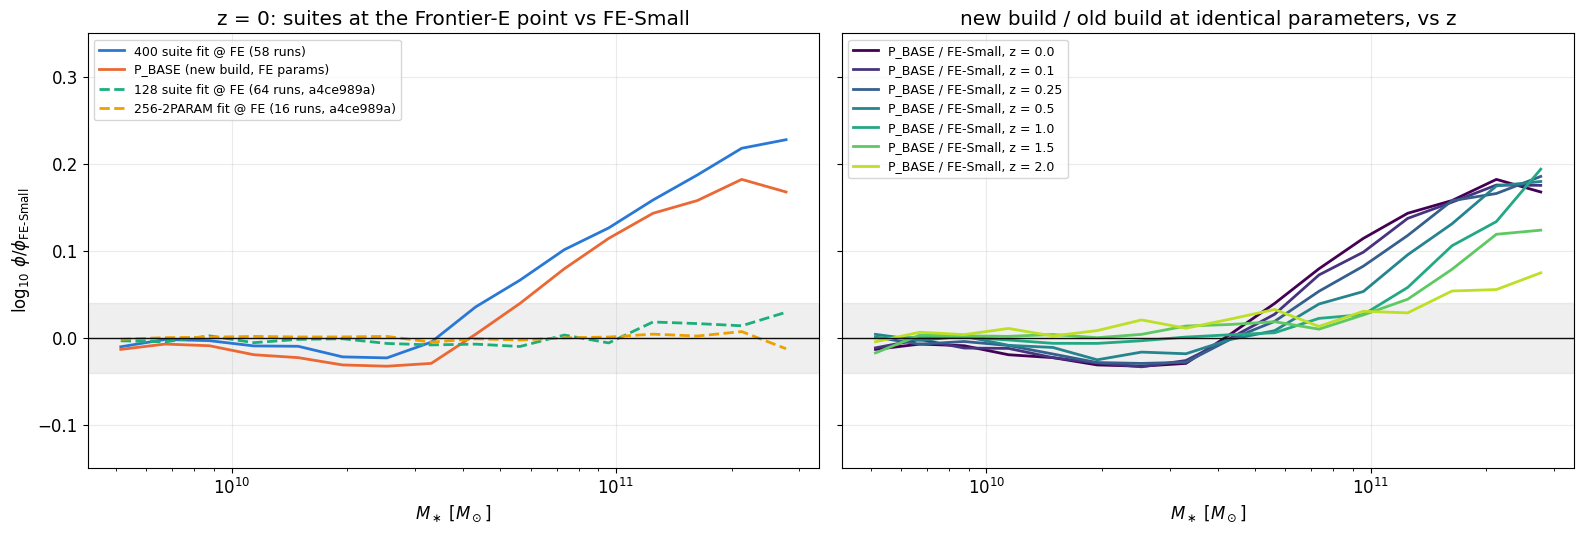

    z  P_BASE/FE-Small @1e11  @2.8e11    nb6: 400-suite excess @1e11  @2.8e11
 0.00                 +0.119   +0.168                          +0.12    +0.19
 0.10                 +0.105   +0.175                          +0.12    +0.20
 0.25                 +0.088   +0.186                           +nan     +nan
 0.50                 +0.060   +0.180                          +0.08    +0.20
 1.00                 +0.032   +0.194                          +0.03    +0.20
 1.50                 +0.029   +0.124                           +nan     +nan
 2.00                 +0.030   +0.075                          +0.03    +0.07


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)
ax = axes[0]
for n, (r, c, ls) in R.items(): ax.plot(X, r, color=c, ls=ls, label=n)
ax.axhline(0, color=COL['FES'], lw=1); ax.axhspan(-0.04, 0.04, color='gray', alpha=0.12)
ax.set_xscale('log'); ax.set_xlabel(r'$M_\ast\;[M_\odot]$'); ax.set_ylabel(r'$\log_{10}\,\phi / \phi_{\rm FE\text{-}Small}$')
ax.set_title('z = 0: suites at the Frontier-E point vs FE-Small'); ax.legend(fontsize=9, loc='upper left'); ax.set_ylim(-0.15, 0.35)
ax = axes[1]
zc = plt.cm.viridis(np.linspace(0, 0.9, len(STEPS)))
for k, ((s, z), c) in enumerate(zip(STEPS.items(), zc)):
    ax.plot(X, L10(GPB[k]) - L10(GFES[k]), color=c, label=f'P_BASE / FE-Small, z = {z}')
ax.axhline(0, color=COL['FES'], lw=1); ax.axhspan(-0.04, 0.04, color='gray', alpha=0.12)
ax.set_xscale('log'); ax.set_xlabel(r'$M_\ast\;[M_\odot]$'); ax.set_title('new build / old build at identical parameters, vs z')
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout(); plt.show()

nb6 = {0.0: (0.12, 0.19), 0.1: (0.12, 0.20), 0.5: (0.08, 0.20), 1.0: (0.03, 0.20), 2.0: (0.03, 0.07)}   # nb6 item 6 (400 excess)
print(f"{'z':>5s} {'P_BASE/FE-Small @1e11':>22s} {'@2.8e11':>8s}   {'nb6: 400-suite excess @1e11':>28s} {'@2.8e11':>8s}")
for k, (s, z) in enumerate(STEPS.items()):
    r = L10(GPB[k]) - L10(GFES[k]); v = np.interp([11.0, LX[-1]], LX, r)
    ref = nb6.get(z, (np.nan, np.nan))
    print(f'{z:5.2f} {v[0]:+22.3f} {v[1]:+8.3f}   {ref[0]:+28.2f} {ref[1]:+8.2f}')

### 3a. All 110 CosmoHydro training extracts (companion to nb6 section F3)

nb6 F3 shows only the three nearest design points. Here every z = 0 extract of the Mar-2026 HAVOCC extraction that
`cosmohydro_emu` was trained on (RUN000-099 training, RUN100-109 held out, cached in
`../data_sims/cosmohydro_400/gsmf_400_training_extracts_mar2026.npz`) is plotted relative to FE-Small, coloured by
e_w (the dominant driver), with the ridge fit at the Frontier-E point, the 58-run fit of Sect. 3 and P_BASE. Design
points scatter over ±0.5 dex because their parameters differ from Frontier-E; the fit at the FE point, the P_BASE run at
exactly the FE parameters and the fit to the 58-run tarball subset all sit on the same +0.11 / +0.20 dex curve.
The output embedded below was rendered off-cluster (no P_BASE / 58-run curves); re-running the notebook on Polaris adds them.


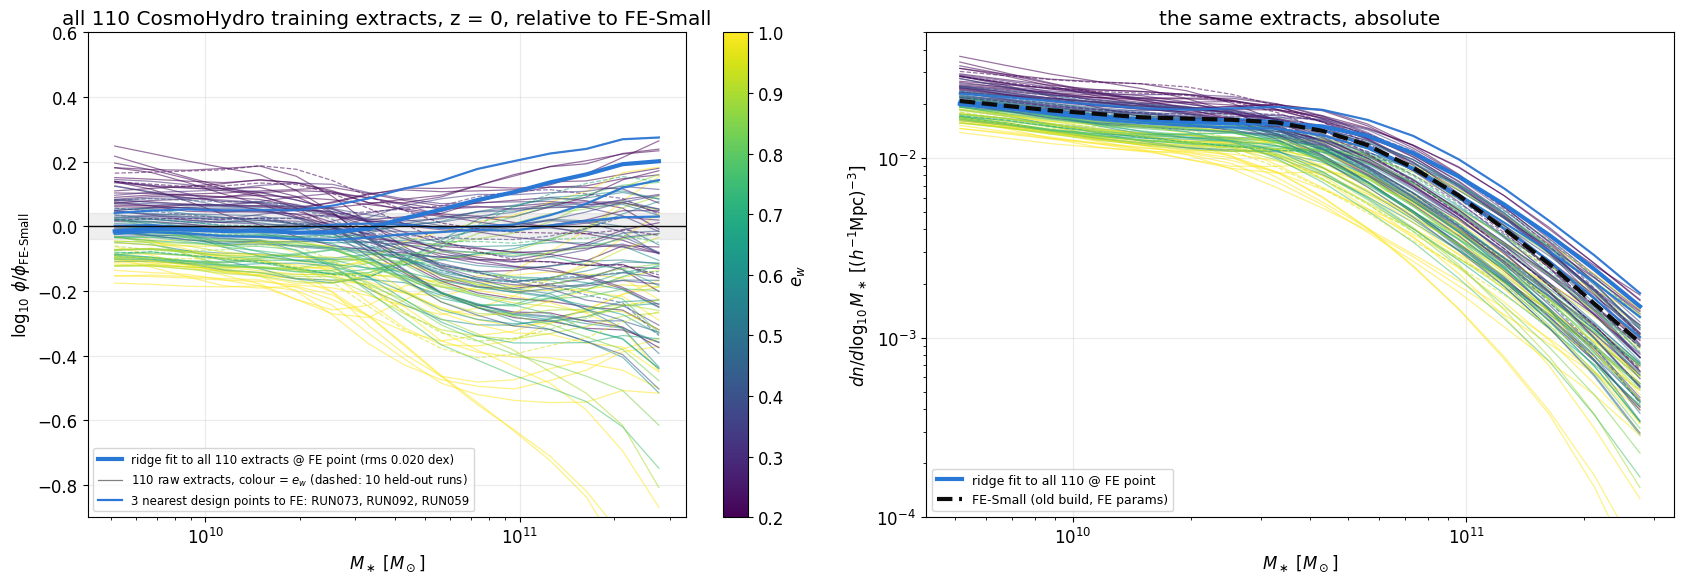

110-extract fit / FE-Small at 3e10, 1e11, 2e11, 2.8e11 Msun:-0.008 +0.110 +0.185 +0.201
nearest design points to the FE point (distance, kappa_w, e_w, M_seed/1e6, v_kin/1e4, eps/10, omega_m, sigma_8; log10 ratio to FE-Small at 1e11 / 2.8e11):
  RUN073  d=0.56  [2.978 0.65  1.059 0.397 0.389 0.147 0.824]  -0.014 / +0.030
  RUN092  d=0.61  [3.839 0.454 0.827 0.154 0.193 0.15  0.844]  +0.006 / +0.143
  RUN059  d=0.65  [3.182 0.319 0.638 0.81  0.548 0.149 0.854]  +0.202 / +0.275
fraction of the 110 extracts above FE-Small at 2.8e11 Msun: 0.30;  at 1e11: 0.25


In [ ]:
# ---- all 110 CosmoHydro training extracts at z = 0 (RUN000-099 = emulator training set, RUN100-109 = held out)
# Source: the Mar-2026 HAVOCC extraction that cosmohydro_emu was trained on
# (CosmoHydro/data/scidac-400MPC_RUNS_5SG_2COSMO_PARAM-extracts_20260323/RUNxxx/extract/GalStellarMassFunction_<step>.txt),
# cached in this repo as ../data_sims/cosmohydro_400/gsmf_400_training_extracts_mar2026.npz (7 snapshots, 39 bins, design).
CT = np.load('../data_sims/cosmohydro_400/gsmf_400_training_extracts_mar2026.npz')
assert np.allclose(CT['mass'], xg)
GT = CT['gsmf'][:, list(CT['steps']).index(624), :][:, SEL]            # (110, 16) at z = 0
XT = CT['design_scaled']                                               # (110, 7) [kappa_w, e_w, M_seed/1e6, v_kin/1e4, eps/10, om, s8]
fitT, rmsT = ridge_fit(XT, L10(GT))
ref0 = L10(GFES[0])
box_lo, box_hi = np.array([2, 0.2, 0.6, 0.1, 0.02]), np.array([4, 1, 1.2, 1.2, 1.2])
dist = np.sqrt((((XT[:, :5] - P5) / (box_hi - box_lo))**2).sum(1) + (((XT[:, 5:] - P7[5:]) / np.array([0.035, 0.2]))**2).sum(1))
near = np.argsort(dist)[:3]
ew = XT[:, 1]; cmap = plt.cm.viridis; norm = plt.Normalize(0.2, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
ax = axes[0]
for i in range(len(GT)):
    ax.plot(X, L10(GT[i]) - ref0, color=cmap(norm(ew[i])), lw=0.9, alpha=0.55, ls='-' if i < 100 else '--')
for i in near:
    ax.plot(X, L10(GT[i]) - ref0, color=COL['400'], lw=1.6, alpha=0.9)
ax.plot(X, fitT(P7)[0] - ref0, color=COL['400'], lw=3, label=f'ridge fit to all 110 extracts @ FE point (rms {rmsT:.3f} dex)')
if 'R' in globals():
    ax.plot(X, R['400 suite fit @ FE (58 runs)'][0], color=COL['400'], lw=2, ls=':', label='ridge fit to the 58 Feb-2026 tarball runs @ FE')
if 'GPB' in globals():
    ax.plot(X, L10(GPB[0]) - ref0, color=COL['PB'], lw=3, label='P_BASE (new build, exactly FE params)')
ax.plot([], [], color='gray', lw=0.9, label='110 raw extracts, colour = $e_w$ (dashed: 10 held-out runs)')
ax.plot([], [], color=COL['400'], lw=1.6, label='3 nearest design points to FE: ' + ', '.join(f'RUN{i:03d}' for i in near))
ax.axhline(0, color=COL['FES'], lw=1); ax.axhspan(-0.04, 0.04, color='gray', alpha=0.12)
ax.set_xscale('log'); ax.set_ylim(-0.9, 0.6); ax.set_xlabel(r'$M_\ast\;[M_\odot]$'); ax.set_ylabel(r'$\log_{10}\,\phi / \phi_{\rm FE\text{-}Small}$')
ax.set_title('all 110 CosmoHydro training extracts, z = 0, relative to FE-Small'); ax.legend(fontsize=8.5, loc='lower left')
plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label=r'$e_w$')
ax = axes[1]
for i in range(len(GT)):
    ax.plot(X, GT[i], color=cmap(norm(ew[i])), lw=0.9, alpha=0.55, ls='-' if i < 100 else '--')
for i in near:
    ax.plot(X, GT[i], color=COL['400'], lw=1.6, alpha=0.9)
ax.plot(X, 10**fitT(P7)[0], color=COL['400'], lw=3, label='ridge fit to all 110 @ FE point')
if 'GPB' in globals(): ax.plot(X, GPB[0], color=COL['PB'], lw=3, label='P_BASE')
ax.plot(X, GFES[0], color=COL['FES'], lw=3, ls='--', label='FE-Small (old build, FE params)')
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_ylim(1e-4, 5e-2); ax.set_xlabel(r'$M_\ast\;[M_\odot]$'); ax.set_ylabel(r'$dn/d\log_{10}M_\ast\;[(h^{-1}{\rm Mpc})^{-3}]$')
ax.set_title('the same extracts, absolute'); ax.legend(fontsize=9, loc='lower left')
plt.tight_layout(); plt.show()

v = np.interp([10.5, 11.0, 11.3, LX[-1]], LX, fitT(P7)[0] - ref0)
print(f'{"110-extract fit / FE-Small at 3e10, 1e11, 2e11, 2.8e11 Msun:":58s}' + ' '.join(f'{x:+.3f}' for x in v))
print('nearest design points to the FE point (distance, kappa_w, e_w, M_seed/1e6, v_kin/1e4, eps/10, omega_m, sigma_8; log10 ratio to FE-Small at 1e11 / 2.8e11):')
for i in near:
    r = L10(GT[i]) - ref0
    print(f'  RUN{i:03d}  d={dist[i]:.2f}  {np.round(XT[i], 3)}  {r[i11]:+.3f} / {r[-1]:+.3f}')
print(f'fraction of the 110 extracts above FE-Small at 2.8e11 Msun: {(L10(GT[:, -1]) > ref0[-1]).mean():.2f};  at 1e11: {(L10(GT[:, i11]) > ref0[i11]).mean():.2f}')


closure: 400-suite fit vs new-build 256 runs at other cosmologies (same FE subgrid parameters)
  P_BASE: omega_m=0.1418 sigma_8=0.8102: 400 fit - run, max |.| below 2e11 = 0.031 dex; top bins [0.036 0.06 ]
  P_MH_S7: omega_m=0.1550 sigma_8=0.7: 400 fit - run, max |.| below 2e11 = 0.034 dex; top bins [0.049 0.071]
  P_MH_S9: omega_m=0.1550 sigma_8=0.9: 400 fit - run, max |.| below 2e11 = 0.054 dex; top bins [0.071 0.119]


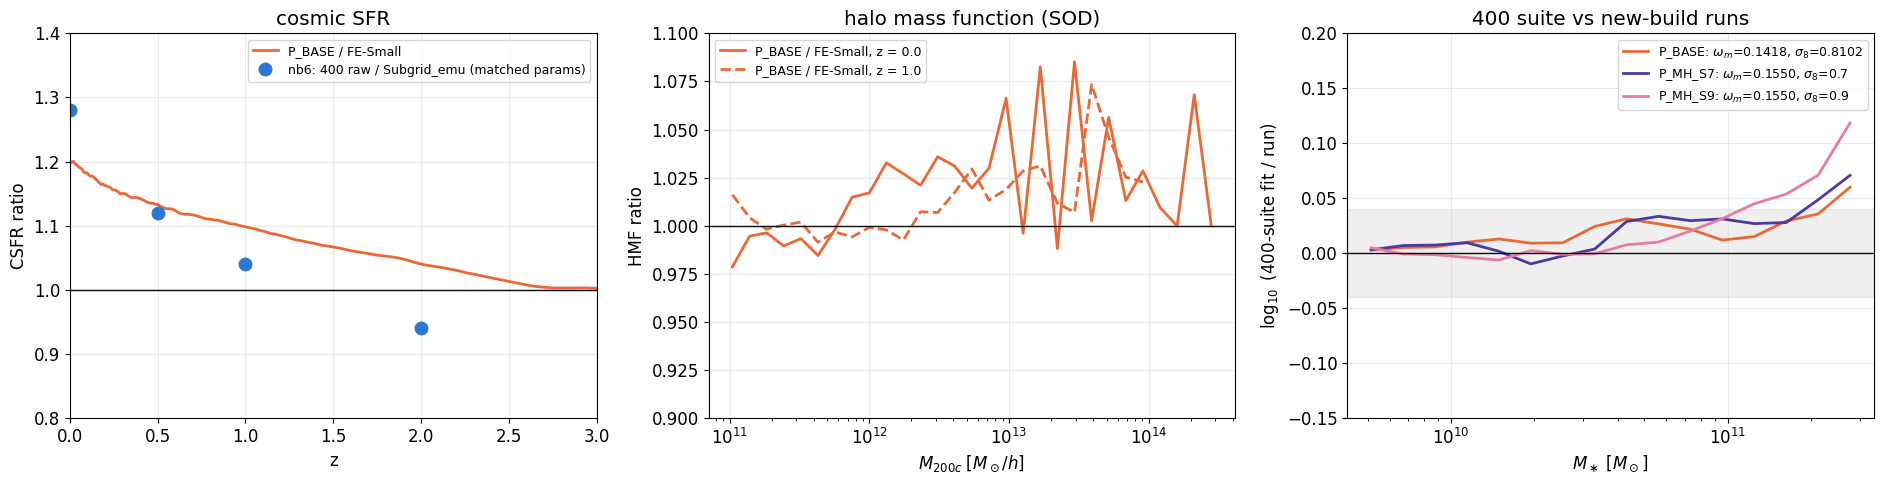

CSFR P_BASE/FE-Small z=0: 1.198
CSFR P_BASE/FE-Small z=0.5: 1.133
CSFR P_BASE/FE-Small z=1: 1.098
CSFR P_BASE/FE-Small z=2: 1.041


In [12]:
# CSFR and HMF at identical parameters; closure at other cosmologies with the same new build
cs_pb = np.loadtxt(f'{PB}/analysis_pipeline/extract/CSFR.txt'); cs_fe = np.loadtxt(f'{FES_EXT}/CSFR.txt')
ag = np.linspace(0.2, 1.0, 400)
ratio = np.interp(ag, cs_pb[:, 0], cs_pb[:, 1]) / np.interp(ag, cs_fe[:, 0], cs_fe[:, 1])
sm = lambda y, w=9: np.convolve(y, np.ones(w), mode='same') / np.convolve(np.ones_like(y), np.ones(w), mode='same')   # edge-safe running mean
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
ax = axes[0]
ax.plot(1 / ag - 1, sm(ratio), color=COL['PB'], label='P_BASE / FE-Small')
ax.axhline(1, color=COL['FES'], lw=1)
for z, v in {0: 1.28, 0.5: 1.12, 1: 1.04, 2: 0.94}.items():
    ax.plot(z, v, 'o', ms=9, color=COL['400'], label='nb6: 400 raw / Subgrid_emu (matched params)' if z == 0 else None)
ax.set_xlabel('z'); ax.set_ylabel('CSFR ratio'); ax.set_xlim(0, 3); ax.set_ylim(0.8, 1.4); ax.legend(fontsize=9); ax.set_title('cosmic SFR')
ax = axes[1]
for s, ls in [(624, '-'), (310, '--')]:
    A = np.genfromtxt(f'{PB}/analysis_pipeline/extract/HaloMassFunction_{s}.txt', names=True)
    B = np.genfromtxt(f'{FES_EXT}/HaloMassFunction_{s}.txt', names=True)
    ok = (A['halo_counts'] >= 20) & (B['halo_counts'] >= 20) & (A['Halo_Mass'] > 1e11)
    ax.plot(A['Halo_Mass'][ok], A['HMF_SOD'][ok] / B['HMF_SOD'][ok], color=COL['PB'], ls=ls, label=f'P_BASE / FE-Small, z = {STEPS[s]}')
ax.axhline(1, color=COL['FES'], lw=1); ax.set_xscale('log'); ax.set_ylim(0.9, 1.1)
ax.set_xlabel(r'$M_{200c}\;[M_\odot/h]$'); ax.set_ylabel('HMF ratio'); ax.legend(fontsize=9); ax.set_title('halo mass function (SOD)')
ax = axes[2]
print('closure: 400-suite fit vs new-build 256 runs at other cosmologies (same FE subgrid parameters)')
for n, c in [('P_BASE', COL['PB']), ('P_MH_S7', COL['cosmo']), ('P_MH_S9', COL['dev'])]:
    d = read_indat(f'{COSMO}/SCIDAC_COSMO_{n}/params/indat.params')
    om = float(d['OMEGA_CDM']) * float(d['HUBBLE'])**2 + float(d['DEUT']); s8 = float(d['SS8'])
    g = L10(read_gsmf(f'{COSMO}/SCIDAC_COSMO_{n}/analysis_pipeline/extract/GalStellarMassFunction_624.txt')[1][SEL])
    r = fit400(np.r_[P5, om, s8])[0] - g
    ax.plot(X, r, color=c, label=f'{n}: $\\omega_m$={om:.4f}, $\\sigma_8$={s8}')
    print(f'  {n}: omega_m={om:.4f} sigma_8={s8}: 400 fit - run, max |.| below 2e11 = {np.nanmax(np.abs(r[X < 2e11])):.3f} dex; top bins', np.round(r[-2:], 3))
ax.axhline(0, color=COL['FES'], lw=1); ax.axhspan(-0.04, 0.04, color='gray', alpha=0.12); ax.set_xscale('log'); ax.set_ylim(-0.15, 0.2)
ax.set_xlabel(r'$M_\ast\;[M_\odot]$'); ax.set_ylabel(r'$\log_{10}$ (400-suite fit / run)'); ax.legend(fontsize=9); ax.set_title('400 suite vs new-build runs')
plt.tight_layout(); plt.show()
for z in [0, 0.5, 1, 2]:
    print(f'CSFR P_BASE/FE-Small z={z}: {np.interp(1 / (1 + z), ag, sm(ratio)):.3f}')

**Sect. 3 verdict.** With parameters, box, resolution and ICs fixed, the newer build alone produces the
400-suite signature: 3-7 % *fewer* galaxies at 1-3×10¹⁰ M☉, the crossover at ≈4×10¹⁰ M☉, then +0.12 dex at
10¹¹ M☉ and +0.17 dex at 2.8×10¹¹ M☉; the same redshift trend as nb6 item 6 (10¹¹ excess fading by z = 1, the
2.8×10¹¹ excess persisting to z = 1, small by z = 2); a CSFR boost growing towards z = 0 (item 7); unchanged
haloes (item 4). Both old-build suites (128 h⁻¹Mpc and 256 h⁻¹Mpc) agree with FE-Small within the fit
scatter, so box size and resolution play no role. The 400-suite fit also reproduces the new-build runs at
ωₘ = 0.155 within 0.034 dex (σ₈ = 0.7) and 0.054 dex (σ₈ = 0.9) below 2×10¹¹ M☉, at the corner of the design where
the fit is least constrained. The residual 400-fit/P_BASE difference
(≤ 0.03 dex below 10¹¹, 0.03-0.06 dex in the top two bins) is of the order of the fit error plus
256-vs-400 box sampling at the massive end.

## 4. Which build did the 400 runs use? A per-particle fingerprint

With no build record for the 400 runs, the build is identified from a quantity that (i) differs between
the builds and (ii) does not depend on the subgrid or cosmological parameters: the fraction of its initial mass
that a star particle retains, as a function of its formation epoch (stellar mass loss/enrichment, the
`CHEM_USE_INIT_STAR_MASS` switch). Star particles inherit the full gas-particle mass, and the baryon particle
mass is identical in every suite (same ω_b, h and 0.25 h⁻¹Mpc spacing).

Sources: OpenCosmo `galaxyparticles/star_particles` (`mass`, `initial_star_mass`, `age` = formation scale factor) for
400 RUN000/RUN001 and the 128 runs; raw GenericIO `galaxyparticles` + `galaxyparticles.subgrid` (`mbh/vw` = initial
mass for stars, `tage`) for FE-Small and P_BASE (1/8 of the sub-files, which is a random spatial subsample).

In [13]:
ABINS = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]); AC = 0.5 * (ABINS[1:] + ABINS[:-1])
def med_curve(r, a): return np.array([np.median(r[(a >= lo) & (a < hi)]) for lo, hi in zip(ABINS[:-1], ABINS[1:])])
def fp_h5(f):
    with h5py.File(f) as f5:
        d = f5['star_particles/data']; return med_curve(d['mass'][:] / d['initial_star_mass'][:], d['age'][:])
def fp_gio(base, sg, stride=8):
    n = gio_nfiles(base); files = list(range(0, n, stride))
    p = gio_read(base, ['id', 'mass', 'mask'], files); q = gio_read(sg, ['id', 'mask', 'mbh/vw', 'tage'], files)
    s1, s2 = p['mask'] == 22, q['mask'] == 22
    o1, o2 = np.argsort(p['id'][s1]), np.argsort(q['id'][s2]); assert np.array_equal(p['id'][s1][o1], q['id'][s2][o2])
    return med_curve(p['mass'][s1][o1] / q['mbh/vw'][s2][o2], q['tage'][s2][o2])

FPR = {}
FPR['400 RUN000'] = fp_h5(f'{M400}/OpenCosmo/RUN000/output/step_624/galaxyparticles/m000p-624.galaxyparticles.0.hdf5')
FPR['400 RUN001'] = fp_h5(f'{M400}/OpenCosmo/RUN001/output/step_624/galaxyparticles/m000p-624.galaxyparticles.0.hdf5')
FPR['FE-Small (942a84f9)'] = fp_gio(f'{FES}/analysis/m000p-624.galaxyparticles', f'{FES}/analysis/m000p-624.galaxyparticles.subgrid')
_pb = f'{PB}/analysis/galaxyparticles/step_624/m000p-624'
FPR['P_BASE (67cebcfb)'] = fp_gio(f'{_pb}.galaxyparticles', f'{_pb}.subgrid.galaxyparticles')
fp128 = {}
for d in sorted(glob.glob(f'{R128H5}/KAPPA_*')):
    f = glob.glob(f'{d}/output/step_624/galaxyparticles/*.hdf5')
    if f: fp128[os.path.basename(d)] = fp_h5(f[0])
F128 = np.array(list(fp128.values()))
print(f"{'a_form bin':34s}" + ''.join(f'{a:7.2f}' for a in AC))
print(f"{'128 suite, min over %d runs' % len(F128):34s}" + ''.join(f'{v:7.3f}' for v in F128.min(0)))
print(f"{'128 suite, max over %d runs' % len(F128):34s}" + ''.join(f'{v:7.3f}' for v in F128.max(0)))
for n, v in FPR.items(): print(f'{n:34s}' + ''.join(f'{x:7.3f}' for x in v))
k = np.argmin(abs(AC - 0.55))
print(f'\nat a_form = 0.5-0.6: 128-suite range {F128[:, k].min():.3f}-{F128[:, k].max():.3f};  gap to 400 runs: '
      f"{FPR['400 RUN000'][k] - F128[:, k].max():+.3f}, {FPR['400 RUN001'][k] - F128[:, k].max():+.3f};  "
      f"|400 RUN000 - P_BASE| max over bins = {np.max(np.abs(FPR['400 RUN000'] - FPR['P_BASE (67cebcfb)'])):.3f}")

a_form bin                           0.15   0.25   0.35   0.45   0.55   0.65   0.75   0.85
128 suite, min over 64 runs         0.714  0.693  0.681  0.671  0.659  0.658  0.669  0.694
128 suite, max over 64 runs         0.754  0.731  0.719  0.710  0.703  0.701  0.701  0.707
400 RUN000                          0.768  0.751  0.743  0.737  0.733  0.732  0.736  0.746
400 RUN001                          0.765  0.748  0.738  0.730  0.723  0.721  0.729  0.747
FE-Small (942a84f9)                 0.730  0.708  0.698  0.692  0.688  0.686  0.689  0.702
P_BASE (67cebcfb)                   0.765  0.749  0.741  0.737  0.734  0.733  0.734  0.743

at a_form = 0.5-0.6: 128-suite range 0.659-0.703;  gap to 400 runs: +0.029, +0.019;  |400 RUN000 - P_BASE| max over bins = 0.003


The three raw 400 copies (RUN008/032/040) carry no galaxy particles, only full z = 0 snapshots without
formation times. For them, the z = 0 star-particle mass in units of the baryon particle mass m_b is the fingerprint
(one sub-file ≈ 1/64-1/128 of the box per run). It is less clean than the curve above because it also depends on the
star-formation history, so it is compared with all 64 runs of the 128 suite to show the parameter-driven spread.

In [14]:
rho_c = 2.77536627e11                                   # h^2 Msun / Mpc^3
m_b = rho_c * FP['Omega_b_h2'] / h**2 * 0.25**3          # Msun/h, identical for every suite
def snap_star_mass(f, files=(0,)):
    d = gio_read(f, ['mask', 'mass'], files=list(files)); s = np.isin(d['mask'], [22, 23])
    return d['mass'][s] / m_b
SN = {r: snap_star_mass(f'{R400}/{r}/output/full_snapshots/step_624/m000p.full.mpicosmo.624') for r in ['RUN008', 'RUN032', 'RUN040']}
SN['P_BASE'] = snap_star_mass(f'{PB}/output/full_snapshots/step_624/m000p.full.mpicosmo.624')
SN['FE-Small'] = snap_star_mass(f'{FES}/output/m000p.full.mpicosmo.624')
sn128 = {}
for d in sorted(glob.glob(f'{S128}/KAPPA_*')):
    f = f'{d}/output/full_snapshots/step_624/m000p.full.mpicosmo.624'
    if os.path.exists(f): sn128[os.path.basename(d)] = np.median(snap_star_mass(f))
print(f'm_b = {m_b:.4e} Msun/h')
v128 = np.array(list(sn128.values()))
print(f'128 suite ({len(v128)} runs): median m*/m_b  min {v128.min():.3f}  median {np.median(v128):.3f}  max {v128.max():.3f}')
for n, v in SN.items(): print(f'{n:9s} median m*/m_b = {np.median(v):.3f}   (N stars in sub-file: {len(v)})')

m_b = 2.1238e+08 Msun/h
128 suite (64 runs): median m*/m_b  min 0.707  median 0.726  max 0.739
RUN008    median m*/m_b = 0.744   (N stars in sub-file: 2436676)
RUN032    median m*/m_b = 0.768   (N stars in sub-file: 3737497)
RUN040    median m*/m_b = 0.766   (N stars in sub-file: 2398877)
P_BASE    median m*/m_b = 0.773   (N stars in sub-file: 363090)
FE-Small  median m*/m_b = 0.732   (N stars in sub-file: 310892)


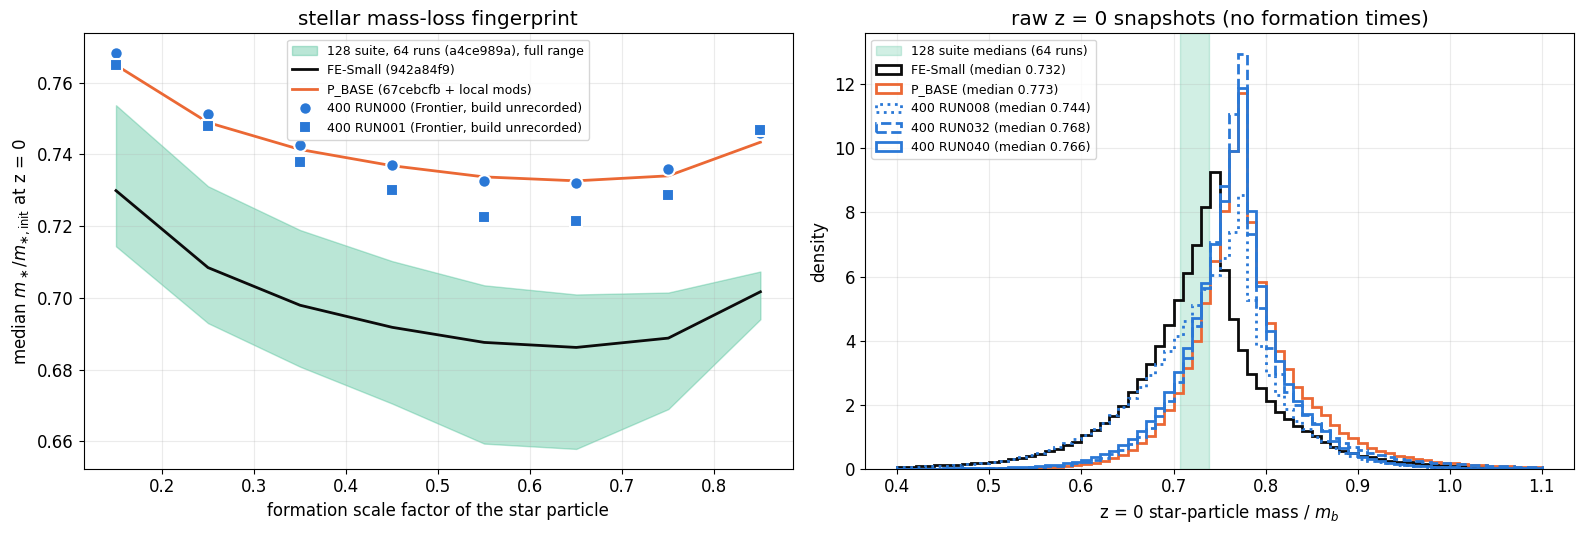

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
ax = axes[0]
ax.fill_between(AC, F128.min(0), F128.max(0), color=COL['128'], alpha=0.3, label=f'128 suite, {len(F128)} runs (a4ce989a), full range')
ax.plot(AC, FPR['FE-Small (942a84f9)'], color=COL['FES'], label='FE-Small (942a84f9)')
ax.plot(AC, FPR['P_BASE (67cebcfb)'], color=COL['PB'], label='P_BASE (67cebcfb + local mods)')
for n, mk in [('400 RUN000', 'o'), ('400 RUN001', 's')]:
    ax.plot(AC, FPR[n], mk, ms=9, color=COL['400'], mec='white', mew=1.5, label=n + ' (Frontier, build unrecorded)')
ax.set_xlabel('formation scale factor of the star particle'); ax.set_ylabel(r'median $m_\ast / m_{\ast,\rm init}$ at z = 0')
ax.set_title('stellar mass-loss fingerprint'); ax.legend(fontsize=9)
ax = axes[1]
bins = np.linspace(0.4, 1.1, 71)
ax.axvspan(v128.min(), v128.max(), color=COL['128'], alpha=0.2, label=f'128 suite medians ({len(v128)} runs)')
for n, c, ls in [('FE-Small', COL['FES'], '-'), ('P_BASE', COL['PB'], '-'), ('RUN008', COL['400'], ':'), ('RUN032', COL['400'], '--'), ('RUN040', COL['400'], '-')]:
    ax.hist(SN[n], bins, density=True, histtype='step', color=c, ls=ls, lw=2, label=(n if n in ('FE-Small', 'P_BASE') else f'400 {n}') + f' (median {np.median(SN[n]):.3f})')
ax.set_xlabel(r'z = 0 star-particle mass / $m_b$'); ax.set_ylabel('density'); ax.legend(fontsize=9, loc='upper left')
ax.set_title('raw z = 0 snapshots (no formation times)')
plt.tight_layout(); plt.show()

**Sect. 4 verdict.** The retained-mass curve depends only weakly on the physics parameters: the 64 runs of the 128 suite,
spanning the whole 5-parameter design, fall in a band 0.04 wide (0.659-0.703 at a_form = 0.55). FE-Small (a different
box and build, same switch setting) sits inside it at 0.688. P_BASE is at 0.734, above the band's *maximum* at every epoch.
**400 RUN000 coincides with P_BASE to ≤ 0.003 in every bin** despite a different cosmology and subgrid parameters, and
RUN001 (a corner of the design: v_kin = 1000 km/s, ε = 0.2, M_seed = 2×10⁶, σ₈ = 0.9) is also above the old-build
maximum. In the raw z = 0 snapshots (median m*/m_b; 128 suite 0.707-0.739, FE-Small 0.732, P_BASE 0.773), RUN032
(0.768) and RUN040 (0.766) sit with P_BASE. RUN008 (0.744; v_kin = 12000 km/s, ε = 12, ωₘ = 0.12, the strongest-feedback
corner) is just above the 128 maximum and on its own is not decisive. So the 400 runs were produced with the
P_BASE-type configuration (67cebcfb-era code with `CHEM_USE_INIT_STAR_MASS` off), not with the build of the 128 suite
or Frontier-E(-Small).

## 5. Which change? The 128 h⁻¹Mpc development runs of 2025

`/eagle/CosDiscover/nfrontiere/Default_*` holds 128 h⁻¹Mpc runs at the Frontier-E parameters and the same ICs as the 128 suite
(`I_SEED 12191992`), made during model development between the FE-Small build (Jan 2025) and the P_BASE build (Nov 2025).
Each is compared with the 128-suite fit at the FE point (old build, same ICs) and fingerprinted as in Sect. 4.

In [16]:
ref128 = fit128(P5)[0]
DEV = []
for d in sorted(glob.glob(f'{NF}/Default_*')):
    if not os.path.exists(f'{d}/params/indat.params') or float(read_indat(f'{d}/params/indat.params')['RL']) != 128: continue
    g = sorted(glob.glob(f'{d}/analysis_pipeline/extract*/GalStellarMassFunction_624.txt'))
    if not g: continue
    b, t = build_of(d)
    if t == '-' and os.path.exists(f'{d}/hacc_tpm'): t = datetime.date.fromtimestamp(os.path.getmtime(f'{d}/hacc_tpm')).isoformat()
    r = L10(read_gsmf(g[-1])[1][SEL]) - ref128
    base, sg = f'{d}/analysis/m000p-624.galaxyparticles', f'{d}/analysis/m000p-624.subgrid.galaxyparticles'
    fpv = fp_gio(base, sg, stride=16)[4] if (os.path.exists(base) and os.path.exists(sg)) else np.nan
    DEV.append(dict(name=os.path.basename(d), build=b, date=t, r=r, fp=fpv))
DEV.sort(key=lambda e: e['date'])
print(f"{'binary date':11s} {'run':62s} {'build':22s} {'m/m0 @a=.55':>11s}  dlog phi vs 128-suite@FE: {'3e10':>6s} {'1e11':>6s} {'2.8e11':>6s}")
for e in DEV:
    v = np.interp([10.5, 11.0, LX[-1]], LX, e['r'])
    print(f"{e['date']:11s} {e['name'][:62]:62s} {e['build']:22s} {e['fp']:11.3f}  {'':25s}" + ' '.join(f'{x:+6.3f}' for x in v))
for n, g, fpv in [('FE-Small (256)', GFES[0], FPR['FE-Small (942a84f9)'][4]), ('P_BASE (256, Nov 2025)', GPB[0], FPR['P_BASE (67cebcfb)'][4])]:
    v = np.interp([10.5, 11.0, LX[-1]], LX, L10(g) - ref128)
    print(f"{'':11s} {n:62s} {'':22s} {fpv:11.3f}  {'':25s}" + ' '.join(f'{x:+6.3f}' for x in v))

binary date run                                                            build                  m/m0 @a=.55  dlog phi vs 128-suite@FE:   3e10   1e11 2.8e11
2025-05-24  Default_128MPC_NEW_KIN_JET_E_1.3_V_5100_S_8e5_SS_ZINI_0.25_NOB hacc_hydro--356a9b4d         0.685                           -0.037 +0.068 +0.055
2025-05-27  Default_128MPC_NEW_KIN_JET_E_1.3_V_5100_S_1e6_SS_ZINI_0.25_NOB hacc_hydro--356a9b4d         0.688                           -0.029 +0.006 -0.020
2025-06-04  Default_128MPC_NEW_KIN_JET_E_1.3_V_5100_S_8e5_SS_ZINI_0.25_EOS hacc_hydro--ed32ef12         0.687                           -0.015 +0.032 -0.028
2025-06-07  Default_128MPC_NEW_KIN_JET_E_1.3_V_5100_S_8e5_SS_ZINI_0.25_EOS hacc_hydro--d561adbe         0.686                           -0.008 +0.013 -0.033
2025-06-07  Default_128MPC_NEW_KIN_JET_E_1.3_V_5100_S_8e5_SS_ZINI_0.25_RAD hacc_hydro--e7481729         0.686                           -0.012 +0.020 -0.049
2025-06-08  Default_128MPC_NEW_KIN_JET_E_1.3_V_5100_S_8e5

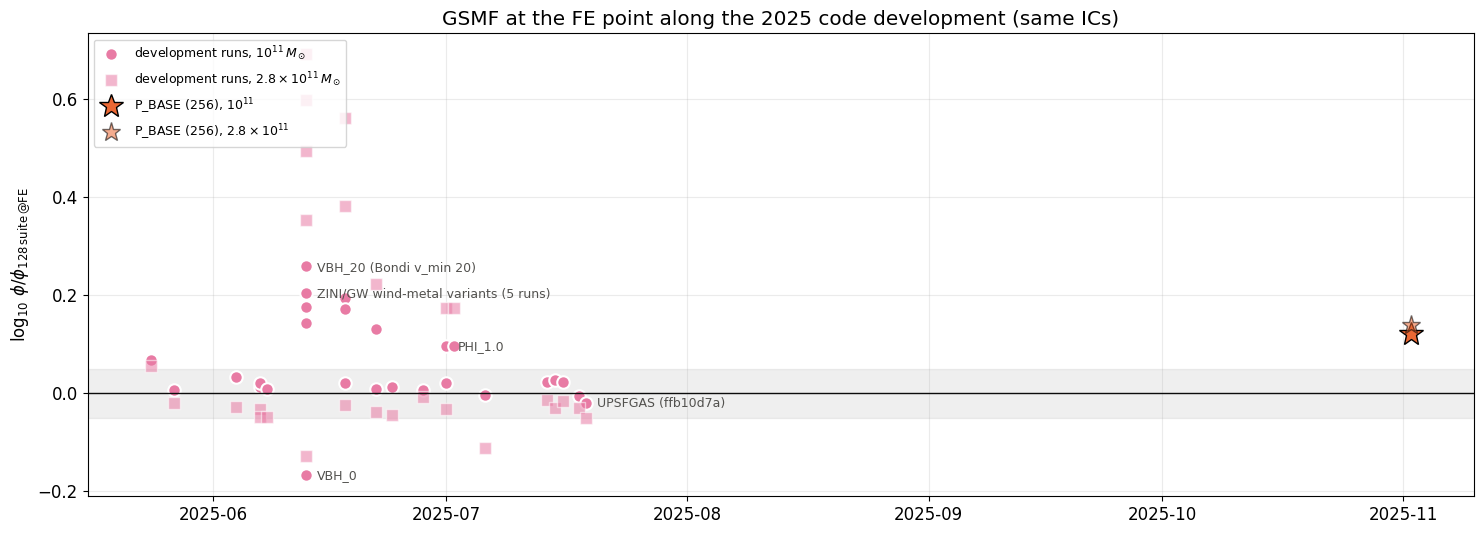

In [17]:
fig, ax = plt.subplots(figsize=(15, 5.5))
dates = [datetime.date.fromisoformat(e['date']) for e in DEV]
y11 = [np.interp(11.0, LX, e['r']) for e in DEV]; y28 = [e['r'][-1] for e in DEV]
ax.plot(dates, y11, 'o', ms=9, color=COL['dev'], mec='white', mew=1.5, label=r'development runs, $10^{11}\,M_\odot$')
ax.plot(dates, y28, 's', ms=8, color=COL['dev'], alpha=0.55, mec='white', label=r'development runs, $2.8\times10^{11}\,M_\odot$')
LAB = {'Default_VBH_20.0': 'VBH_20 (Bondi v_min 20)', 'Default_VBH_0.0': 'VBH_0', 'Default_PHI_1.0': 'PHI_1.0',
       'Default_UPSFGAS': 'UPSFGAS (ffb10d7a)', 'Default_ZINI_0.0_GW_0.0': 'ZINI/GW wind-metal variants (5 runs)'}
for e, d, y in zip(DEV, dates, y11):
    if e['name'] in LAB:
        ax.annotate(LAB[e['name']], (d, y), textcoords='offset points', xytext=(8, -3), fontsize=9, color='#52514e')
dpb = datetime.date(2025, 11, 2)
ax.plot([dpb], [np.interp(11.0, LX, L10(GPB[0]) - ref128)], '*', ms=18, color=COL['PB'], mec='k', label=r'P_BASE (256), $10^{11}$')
ax.plot([dpb], [(L10(GPB[0]) - ref128)[-1]], '*', ms=14, color=COL['PB'], alpha=0.55, mec='k', label=r'P_BASE (256), $2.8\times10^{11}$')
ax.axhline(0, color=COL['FES'], lw=1); ax.axhspan(-0.05, 0.05, color='gray', alpha=0.12)
ax.set_ylabel(r'$\log_{10}\,\phi / \phi_{\rm 128\,suite\,@FE}$'); ax.set_title('GSMF at the FE point along the 2025 code development (same ICs)')
ax.legend(fontsize=9, loc='upper left'); plt.tight_layout(); plt.show()

**Sect. 5 verdict.** Every development run that uses the default model setup (NOBETA, EOSFIX, NEWTAB, UVSMOOTH, the RADFIX
series, UPSFGAS on `ffb10d7a`, 19 Jul 2025) reproduces the old GSMF within ±0.05 dex and has the old mass-loss
fingerprint. The massive-end excess appears in runs that weaken black-hole growth or AGN quenching: `VBH_20.0` (larger
minimum BH velocity in the Bondi rate) gives +0.26/+0.49 dex *without* any change of the mass-loss curve, and
`PHI_1.0` and the `ZINI_*_GW_*` wind/metallicity variants give +0.1-0.2 dex. The mass-retention change first appears in
the Nov 2025 build (P_BASE), and no build between 19 Jul and 2 Nov 2025 exists on Eagle. So the specific commit cannot be
named from here. The data show that (i) the excess is a feature of the code state between `ffb10d7a` and `67cebcfb` + local
switches, and (ii) its massive-end shape is the known response to weaker BH accretion, with the mass-return switch adding a
separate, roughly mass-independent ≈+6 % in stellar mass.

## 6. Mechanism at matched parameters (catalogues): P_BASE vs FE-Small

BRIEF steps 3 and 4 on the two 256 h⁻¹Mpc runs with identical parameters: GSMF with three stellar-mass definitions, centrals vs
satellites (central = most massive galaxy of its FoF halo), BH mass, sSFR and quenched fraction at fixed M*, and the stellar
mass locked in galaxies. Galaxy masses are M☉/h in the catalogue and are divided by h.

In [18]:
GV = ['gal_tag', 'fof_halo_tag', 'gal_mass_star', 'gal_dbscan_mstar', 'gal_2Rhalf_stellar_mass', 'gal_sfr', 'gal_mmagn_mass']
CAT = {'FE-Small': gio_read(f'{FES}/analysis/m000p-624.galaxyproperties', GV),
       'P_BASE': gio_read(glob.glob(f'{PB}/analysis/galaxyproperties/step_624/m000p-624.galaxyproperties')[0], GV)}
def centrals(d):
    o = np.lexsort((-d['gal_mass_star'], d['fof_halo_tag']))
    first = np.r_[True, d['fof_halo_tag'][o][1:] != d['fof_halo_tag'][o][:-1]]
    m = np.zeros(len(o), bool); m[o[first]] = True; return m
for d in CAT.values():
    d['cen'] = centrals(d); d['lm'] = np.log10(d['gal_mass_star'] / h); d['ssfr'] = d['gal_sfr'] / (d['gal_mass_star'] / h)
E = np.arange(9.5, 12.01, 0.25); EC = 0.5 * (E[1:] + E[:-1]); V256 = 256.0**3
def phi(m, sel=None):
    lm = np.log10(m / h); lm = lm if sel is None else lm[sel]
    return np.histogram(lm, E)[0] / V256 / 0.25
def binned(d, y, f=np.median, sel=None, nmin=10):
    out = []
    for lo, hi in zip(E[:-1], E[1:]):
        s = (d['lm'] >= lo) & (d['lm'] < hi) & (True if sel is None else sel)
        out.append(f(y[s]) if s.sum() >= nmin else np.nan)
    return np.array(out)
for n, d in CAT.items(): print(f'{n}: {len(d["gal_tag"])} galaxies, {d["cen"].sum()} centrals')
GR = {}
for lab, key, pop in [('aperture 50 kpc (gal_mass_star)', 'gal_mass_star', None), ('DBSCAN (gal_dbscan_mstar)', 'gal_dbscan_mstar', None),
                      ('2 R_half (gal_2Rhalf_stellar_mass)', 'gal_2Rhalf_stellar_mass', None),
                      ('aperture, centrals', 'gal_mass_star', 'c'), ('aperture, satellites', 'gal_mass_star', 's')]:
    a, b = [phi(CAT[n][key], None if pop is None else (CAT[n]['cen'] if pop == 'c' else ~CAT[n]['cen'])) for n in ['P_BASE', 'FE-Small']]
    GR[lab] = a / b
print(f"\n{'GSMF ratio P_BASE / FE-Small; log M* =':38s}" + ''.join(f'{c:7.2f}' for c in EC))
for k, v in GR.items(): print(f'{k:38s}' + ''.join(f'{x:7.3f}' for x in v))
BH = {n: binned(d, d['gal_mmagn_mass'], sel=d['cen']) for n, d in CAT.items()}
QF = {n: binned(d, (d['ssfr'] < 1e-11).astype(float), np.mean, sel=d['cen']) for n, d in CAT.items()}
SS = {n: binned(d, d['ssfr'], np.mean, sel=d['cen']) for n, d in CAT.items()}
print(f"\n{'centrals':38s}" + ''.join(f'{c:7.2f}' for c in EC))
print(f"{'dlog M_BH (median) P_BASE - FE-Small':38s}" + ''.join(f'{x:+7.3f}' for x in np.log10(BH['P_BASE'] / BH['FE-Small'])))
for n in CAT: print(f"{'quenched fraction (sSFR<1e-11) ' + n:38s}" + ''.join(f'{x:7.3f}' for x in QF[n]))
print(f"{'mean sSFR ratio P_BASE / FE-Small':38s}" + ''.join(f'{x:7.2f}' for x in SS['P_BASE'] / SS['FE-Small']))

FE-Small: 491739 galaxies, 362183 centrals
P_BASE: 489939 galaxies, 361987 centrals

GSMF ratio P_BASE / FE-Small; log M* =   9.62   9.88  10.12  10.38  10.62  10.88  11.12  11.38  11.62  11.88
aperture 50 kpc (gal_mass_star)         1.001  0.982  0.952  0.927  1.002  1.194  1.385  1.511  1.859  2.040
DBSCAN (gal_dbscan_mstar)               1.000  0.983  0.954  0.932  1.012  1.192  1.314  1.366  1.339  1.500
2 R_half (gal_2Rhalf_stellar_mass)      1.001  0.972  0.943  0.924  1.055  1.269  1.453  1.544  1.852  2.500
aperture, centrals                      1.006  0.984  0.950  0.923  1.001  1.198  1.364  1.478  1.822  2.013
aperture, satellites                    0.987  0.975  0.956  0.938  1.004  1.182  1.470  1.688  2.248  2.538



centrals                                 9.62   9.88  10.12  10.38  10.62  10.88  11.12  11.38  11.62  11.88
dlog M_BH (median) P_BASE - FE-Small   -0.076 -0.116 -0.092 -0.102 -0.098 -0.100 -0.157 -0.194 -0.192 -0.179
quenched fraction (sSFR<1e-11) FE-Small  0.365  0.313  0.343  0.424  0.605  0.797  0.940  0.990  0.996  1.000
quenched fraction (sSFR<1e-11) P_BASE   0.387  0.305  0.289  0.329  0.481  0.695  0.877  0.967  0.990  0.994
mean sSFR ratio P_BASE / FE-Small        0.99   1.02   1.11   1.25   1.41   1.67   2.27   3.18   1.96  24.71


In [19]:
# stellar mass in galaxies vs stars formed (nb6 item 8), and total
H0_yr = FP['H0'] / 3.0857e19 * 3.15576e7
def rho_from_csfr(c, Om):
    a, s = c[:, 0], c[:, 1]; ok = a > 0; a, s = a[ok], s[ok]
    return np.trapezoid(s / (a * H0_yr * np.sqrt(Om * a**-3 + 1 - Om)), a)
def rho_from_gsmf(f):
    d = np.loadtxt(f); return np.sum(d[:, 1] * d[:, 0] * np.diff(np.log10(d[:, 0]))[0])
for n, c, g in [('FE-Small', cs_fe, f'{FES_EXT}/GalStellarMassFunction_624.txt'), ('P_BASE', cs_pb, f'{PB}/analysis_pipeline/extract/GalStellarMassFunction_624.txt')]:
    rc, rg = rho_from_csfr(c, FP['Omega_m']), rho_from_gsmf(g)
    rcat = CAT[n]['gal_mass_star'].sum() / h / V256
    print(f'{n:9s}: int CSFR dt = {rc:.3e}, int M* phi (HAVOCC GSMF) = {rg:.3e} Msun (Mpc/h)^-3 -> fraction {rg / rc:.3f};'
          f'  sum of catalogue aperture masses = {rcat:.3e}')
print('ratio of total aperture stellar mass in galaxies P_BASE/FE-Small:',
      round(CAT['P_BASE']['gal_mass_star'].sum() / CAT['FE-Small']['gal_mass_star'].sum(), 3))
print('retained-mass ratio from the fingerprint (a = 0.3-0.8 mean):',
      round(np.mean(FPR['P_BASE (67cebcfb)'][2:7] / FPR['FE-Small (942a84f9)'][2:7]), 3))

FE-Small : int CSFR dt = 1.411e+09, int M* phi (HAVOCC GSMF) = 7.741e+08 Msun (Mpc/h)^-3 -> fraction 0.549;  sum of catalogue aperture masses = 7.719e+08
P_BASE   : int CSFR dt = 1.535e+09, int M* phi (HAVOCC GSMF) = 9.234e+08 Msun (Mpc/h)^-3 -> fraction 0.601;  sum of catalogue aperture masses = 9.206e+08
ratio of total aperture stellar mass in galaxies P_BASE/FE-Small: 1.193
retained-mass ratio from the fingerprint (a = 0.3-0.8 mean): 1.066


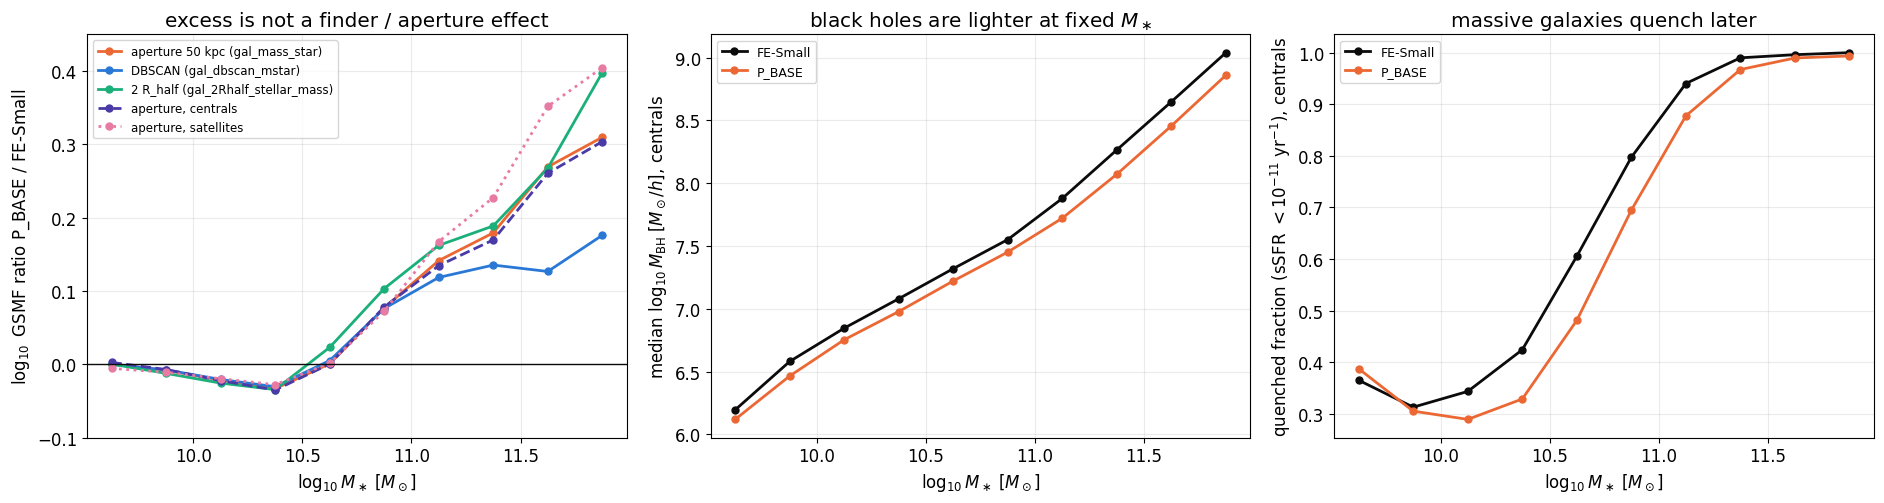

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))
ax = axes[0]
for (k, v), c, ls in zip(GR.items(), [COL['PB'], COL['400'], COL['128'], COL['cosmo'], COL['dev']], ['-', '-', '-', '--', ':']):
    ax.plot(EC, np.log10(v), color=c, ls=ls, marker='o', ms=5, label=k)
ax.axhline(0, color=COL['FES'], lw=1); ax.set_xlabel(r'$\log_{10} M_\ast\;[M_\odot]$'); ax.set_ylabel(r'$\log_{10}$ GSMF ratio P_BASE / FE-Small')
ax.set_title('excess is not a finder / aperture effect'); ax.legend(fontsize=8.5); ax.set_ylim(-0.1, 0.45)
ax = axes[1]
for n, c in [('FE-Small', COL['FES']), ('P_BASE', COL['PB'])]: ax.plot(EC, np.log10(BH[n]), color=c, marker='o', ms=5, label=n)
ax.set_xlabel(r'$\log_{10} M_\ast\;[M_\odot]$'); ax.set_ylabel(r'median $\log_{10} M_{\rm BH}\;[M_\odot/h]$, centrals')
ax.set_title('black holes are lighter at fixed $M_\\ast$'); ax.legend(fontsize=9)
ax = axes[2]
for n, c in [('FE-Small', COL['FES']), ('P_BASE', COL['PB'])]: ax.plot(EC, QF[n], color=c, marker='o', ms=5, label=n)
ax.set_xlabel(r'$\log_{10} M_\ast\;[M_\odot]$'); ax.set_ylabel(r'quenched fraction (sSFR $<10^{-11}$ yr$^{-1}$), centrals')
ax.set_title('massive galaxies quench later'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### 6a. Side effect on the matter power spectrum

CosmoHydro_emu also provides P_hydro(k) (nb2, nb5), so the same build pair is compared for the total-matter P(k)
(HACC `m000p.pk.<step>`; identical ICs, so the ratio carries almost no cosmic variance).

   z      0.5      1.0      2.0      5.0     10.0     20.0   (P_BASE / FE-Small at k [h/Mpc])
 0.0   1.0009   1.0035   1.0120   1.0350   1.0531   1.0596
 1.0   1.0005   1.0024   1.0089   1.0277   1.0416   1.0480


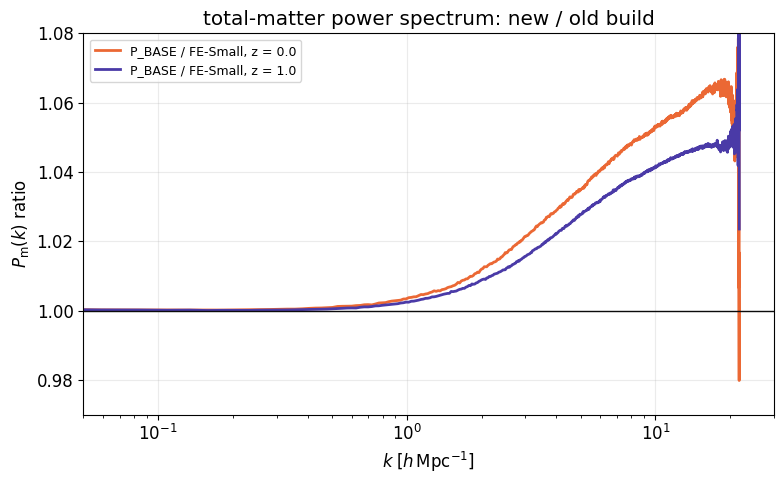

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
print(f"{'z':>4s}" + ''.join(f'{k:>9.1f}' for k in [0.5, 1, 2, 5, 10, 20]) + '   (P_BASE / FE-Small at k [h/Mpc])')
for s, c in [(624, COL['PB']), (310, COL['cosmo'])]:
    fa, fb = f'{PB}/output/power_spectra/m000p.pk.{s}', f'{FES}/output/m000p.pk.{s}'
    if not (os.path.exists(fa) and os.path.exists(fb)): print('missing', s); continue
    a, b = np.loadtxt(fa), np.loadtxt(fb); assert np.allclose(a[:, 0], b[:, 0])
    ax.plot(a[:, 0], a[:, 1] / b[:, 1], color=c, label=f'P_BASE / FE-Small, z = {STEPS[s]}')
    print(f'{STEPS[s]:4.1f}' + ''.join(f'{np.interp(k, a[:, 0], a[:, 1] / b[:, 1]):9.4f}' for k in [0.5, 1, 2, 5, 10, 20]))
ax.axhline(1, color=COL['FES'], lw=1); ax.set_xscale('log'); ax.set_xlim(0.05, 30); ax.set_ylim(0.97, 1.08)
ax.set_xlabel(r'$k\;[h\,{\rm Mpc}^{-1}]$'); ax.set_ylabel(r'$P_{\rm m}(k)$ ratio'); ax.legend(fontsize=9)
ax.set_title('total-matter power spectrum: new / old build'); plt.tight_layout(); plt.show()

### 6b. The same BH signature in the actual 400 runs

The 400 catalogues exist for RUN000 and RUN001 only, at design points far from Frontier-E, so they are compared with the
128 suite at *their own* subgrid parameters: per-run median log M_BH of centrals (from the 128 OpenCosmo catalogues) in
M* bins, ridge-quadratic fit over the 5 subgrid parameters, evaluated at RUN000/RUN001. Cosmology differs (the 128 suite
is at the FE cosmology), and RUN001's M_seed = 2×10⁶ is far outside the 128 design (≤ 1.2×10⁶), so RUN001 is an
extrapolation (a higher seed mass gives heavier BHs). This is a consistency check for RUN000, not a measurement.

In [22]:
EB = np.array([10.25, 10.5, 10.75, 11.0, 11.25, 11.5]); EBC = 0.5 * (EB[1:] + EB[:-1])
def bh_curve(ms, mbh, fof):
    d = {'gal_mass_star': ms, 'fof_halo_tag': fof}; c = centrals(d); lm = np.log10(ms / h)
    return np.array([np.log10(np.median(mbh[c & (lm >= lo) & (lm < hi)])) if (c & (lm >= lo) & (lm < hi)).sum() >= 10 else np.nan
                     for lo, hi in zip(EB[:-1], EB[1:])])
def h5cat(files):
    out = {k: [] for k in ['gal_mass_star', 'gal_mmagn_mass', 'fof_halo_tag']}
    for f in files:
        with h5py.File(f) as f5:
            for k in out: out[k].append(f5['data'][k][:])
    return {k: np.concatenate(v) for k, v in out.items()}
B128, XB = [], []
for d in sorted(glob.glob(f'{R128H5}/KAPPA_*')):
    f = glob.glob(f'{d}/output/step_624/galaxyproperties/*.hdf5')
    if f:
        c = h5cat(f); B128.append(bh_curve(c['gal_mass_star'], c['gal_mmagn_mass'], c['fof_halo_tag'])); XB.append(p128(os.path.basename(d)))
B128, XB = np.array(B128), np.array(XB)
fitB, rmsB = ridge_fit(XB, B128)
print(f'128-suite BH fit: {len(XB)} runs, in-sample rms {rmsB:.3f} dex; design range', np.round(XB.min(0), 3), '-', np.round(XB.max(0), 3))
print(f"{'log M* bin centre':40s}" + ''.join(f'{c:8.3f}' for c in EBC))
c0 = None
for r in ['RUN000', 'RUN001']:
    c = h5cat(sorted(glob.glob(f'{M400}/OpenCosmo/{r}/output/step_624/galaxyproperties/m000p-624.galaxyproperties.[0-9]*.hdf5')))
    if r == 'RUN000': c0 = c
    q = dscale(design_raw[[int(r[3:])]])[0]
    off = bh_curve(c['gal_mass_star'], c['gal_mmagn_mass'], c['fof_halo_tag']) - fitB(q[:5])[0]
    print(f'{r} (params {np.round(q, 3)}): 400 run - 128 fit' + ''.join(f'{x:+8.3f}' for x in off))
_pbfe = []
for n in ['P_BASE', 'FE-Small']:
    d = CAT[n]; _pbfe.append(bh_curve(d['gal_mass_star'], d['gal_mmagn_mass'], d['fof_halo_tag']))
print(f"{'reference: P_BASE - FE-Small':40s}" + ''.join(f'{x:+8.3f}' for x in _pbfe[0] - _pbfe[1]))
print(f"{'reference: FE-Small - 128 fit @ FE':40s}" + ''.join(f'{x:+8.3f}' for x in _pbfe[1] - fitB(P5)[0]))

# HAVOCC check on the 400 suite itself: the Mar-23 training extract of RUN000 vs a histogram of its own catalogue
xe, ge = read_gsmf(f'{M400}/HAvoCC_Mar23/RUN000/extract_lowz/GalStellarMassFunction_624.txt')
le = np.log10(xe); dl = np.diff(le)[0]; edges = np.r_[le - dl / 2, le[-1] + dl / 2]
mine = np.histogram(np.log10(c0['gal_mass_star'] / h), edges)[0] / 400.0**3 / dl
ok = (xe > 5e9) & (xe < 3e11)
print('\n400 RUN000: HAVOCC training extract / own histogram of gal_mass_star (16 emulator bins):', np.round(ge[ok] / mine[ok], 4))

128-suite BH fit: 64 runs, in-sample rms 0.012 dex; design range [2.   0.2  0.6  0.1  0.02] - [4.  1.  1.2 1.2 1.2]
log M* bin centre                         10.375  10.625  10.875  11.125  11.375


RUN000 (params [4.    0.6   0.6   1.2   0.61  0.138 0.8  ]): 400 run - 128 fit  -0.118  -0.092  -0.096  -0.138  -0.134


RUN001 (params [2.    1.    2.    0.1   0.02  0.155 0.9  ]): 400 run - 128 fit  +0.382  +0.064  +0.167  +0.317  +0.302


reference: P_BASE - FE-Small              -0.102  -0.098  -0.100  -0.157  -0.194
reference: FE-Small - 128 fit @ FE        -0.003  +0.005  -0.001  -0.012  -0.000

400 RUN000: HAVOCC training extract / own histogram of gal_mass_star (16 emulator bins): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


**Sect. 6 verdict.** At identical parameters the new build (i) raises the GSMF above 5×10¹⁰ M☉ in *every* stellar-mass
definition (aperture, DBSCAN, 2R½) and for both centrals and satellites, so it is not a galaxy-finder or aperture effect;
(ii) makes central black holes 0.10 dex lighter at fixed M* below 10¹¹ M☉ and 0.16-0.19 dex lighter above it; (iii) lowers
the quenched fraction of 10^10.4-10^11.1 M☉ centrals by 0.06-0.12 and raises their sSFR 1.4-3×; (iv) puts 19 % more stellar
mass into galaxies. The fraction ∫M*φ / ∫CSFR dt is 0.549 (FE-Small) vs 0.601 (P_BASE), reproducing nb6 item 8 (0.54 vs 0.60).
About 6.6 % of the 19 % is the retained-mass change (Sect. 4). Weaker AGN feedback also shows in P(k): less baryonic
suppression, the new build's P_m(k) being ≈1 % higher at k = 2 and 3-5 % higher at k = 5-10 h Mpc⁻¹ at z = 0 (§6a). In the real 400 RUN000 the central BH masses sit 0.09-0.14 dex
below the 128 suite at the same subgrid parameters, the same offset as P_BASE vs FE-Small, while FE-Small itself matches
the 128 fit to ≤ 0.012 dex.

## 7. Summary

| question (BRIEF §5) | answer | evidence |
|---|---|---|
| Parameter slip (hyp. 3)? | **No** | `indat.params` of RUN008/032/040 equal `FinalDesign.txt` in raw units; all other physics keys equal the 128 suite / Frontier-E (§1a) |
| Galaxy-finder settings (hyp. 2, configuration)? | **No** | identical `cosmotools-config.dat`, 50 kpc / 10 / 10 in the catalogue headers (§2); excess in all mass definitions and in centrals and satellites (§6) |
| HAVOCC / post-processing? | **No** | the 400 RUN000 training extract equals a plain histogram of its own catalogue (§6b); for P_BASE / FE-Small catalogue sums equal the extract integrals to 0.3 % (§6); `AGN_RAD_EFF` in the HAVOCC config is a HAVOCC default (§1b) |
| Box size / resolution / cosmology? | **No** | old-build 128 and 256 suites agree with FE-Small at the FE point (§3); same 0.25 h⁻¹Mpc spacing and ICs seed |
| HACC build (hyp. 1)? | **Yes** | a new-build run at the exact FE parameters reproduces the excess, its z-dependence, the CSFR boost and the 0.60 retained fraction (§3, §6); the 400 runs carry that build's star-particle mass-loss fingerprint (§4) |
| Physical mechanism | weaker BH growth → late quenching, plus ≈ +6 % stellar-mass retention | BH 0.1-0.19 dex lighter at fixed M*, lower quenched fractions (§6); `VBH_20` shows that a BH-accretion change alone makes this GSMF shape (§5) |
| Which runs affected? | every 400 run that could be checked | fingerprint: RUN000, RUN001 (per-particle, clean), RUN032, RUN040 (snapshot), RUN008 (snapshot, marginal). The 58-run fit is shifted as a whole, reproduces new-build runs at 3 cosmologies, and has in-sample rms 0.017 dex, i.e. no sub-population of old-build runs. RUN056-109 (except 060, 063) could not be inspected on Eagle |
| Which commit? | not identifiable from here | between `ffb10d7a` (19 Jul 2025, GSMF normal) and `67cebcfb` + local `SF_FULL_SFR` on / `CHEM_USE_INIT_STAR_MASS` off (Nov 2025); HACC repo is private |

Consequence: the 400 h⁻¹Mpc suite (and so CosmoHydro_emu) represents a *different subgrid model* from the one Frontier-E
was calibrated with; the same applies to its P_hydro(k) at k ≳ 2 h Mpc⁻¹ (§6a). At the Frontier-E parameters it gives a 1.3-1.7× higher massive-end GSMF. This is not a sampling error
of the emulator, and it cannot be fixed by re-running cosmotools/HAVOCC.